In [8]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [9]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = 670
obs_mode = "MBI"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values)
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list)

print(interleaved_stds[0])

Interleaved Values
Length:  320
[  4891.    12895.5   -8596.    13342.5    1190.5   12976.    -5411.5
  13045.    -6623.5   13368.5    2486.    12814.   -12740.5   13944.
   9496.5   12967.5  -13235.    13903.    11358.    13094.5   -8040.5
  13293.     7342.5   13117.5    -674.    12906.      334.5   13393.
   3112.    12875.5   -3963.    13650.     4450.    13125.5   -6885.5
  13580.     6726.5   12994.5   -9906.    13737.5    2201.    13172.5
  -6372.5   13278.    -6036.    13547.5    1799.5   12976.5  -12123.5
  14053.     8802.    12981.   -12333.5   13903.    10326.    13109.5
  -7081.    13226.     6317.    13089.     -227.    12805.      -70.5
  13321.5    1057.    13329.    -2102.5   13579.     8027.5   13096.5
  -9776.    13947.5    9101.    13241.   -12201.    13999.     3880.5
  13327.5   -8014.5   13505.5   -4793.5   13695.5     477.5   13135.5
 -10556.    14132.     7209.5   12967.   -10266.    13911.     8276.
  12972.    -4663.    13153.     3708.25  13091.    -2852.   

In [10]:
%%timeit

import copy


copy.deepcopy(interleaved_values)

2.76 µs ± 134 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [11]:
# Loading in previous fit from vampires_calibration
filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/675-50_no_IMR_offset_iterate_on_any_improvement_with_dichroic_best_fit_old_fit_values.txt"
with open(filename, "r") as f:
    past_fit = json.load(f)
past_fit.pop("wollaston", None)
past_fit.setdefault("image_rotator", {})
past_fit["image_rotator"].pop("delta_theta", None)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = 0
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
em_gain = 1.19 # from EM gain measurements

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.642  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        }
    }
}

{'dichroic': {'phi': -1.3938711574213065, 'epsilon': 0.005209238748378545, 'theta': -7.445605323627496}, 'flc': {'phi': 2.8701090006190295, 'delta_theta': 4.999999119252516}, 'optics': {'phi': -0.7396375911802608, 'epsilon': 0.002321229389085099, 'theta': 24.716019860602074}, 'image_rotator': {'phi': 2.0201674353850407}, 'hwp': {'phi': 2.9156665754145195, 'delta_theta': -1.2272137742157683}, 'lp': {'theta': -0.10967918339926608}}


In [12]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[ 0.56545294  0.56544879 -0.00216485  0.        ]
 [ 0.56545294  0.56544879 -0.00216485  0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': -1.3938711574213065, 'epsilon': 0.005209238748378545, 'theta': -7.445605323627496}, 'flc': {'phi': 2.8701090006190295, 'delta_theta': 4.999999119252516}, 'optics': {'phi': -0.7396375911802608, 'epsilon': 0.002321229389085099, 'theta': 24.716019860602074}, 'image_rotator': {'phi': 2.0201674353850407}, 'hwp': {'phi': 2.9156665754145195, 'delta_theta': -1.2272137742157683}, 'lp': {'theta': -0.10967918339926608}}
logl value: 13339.571660439402


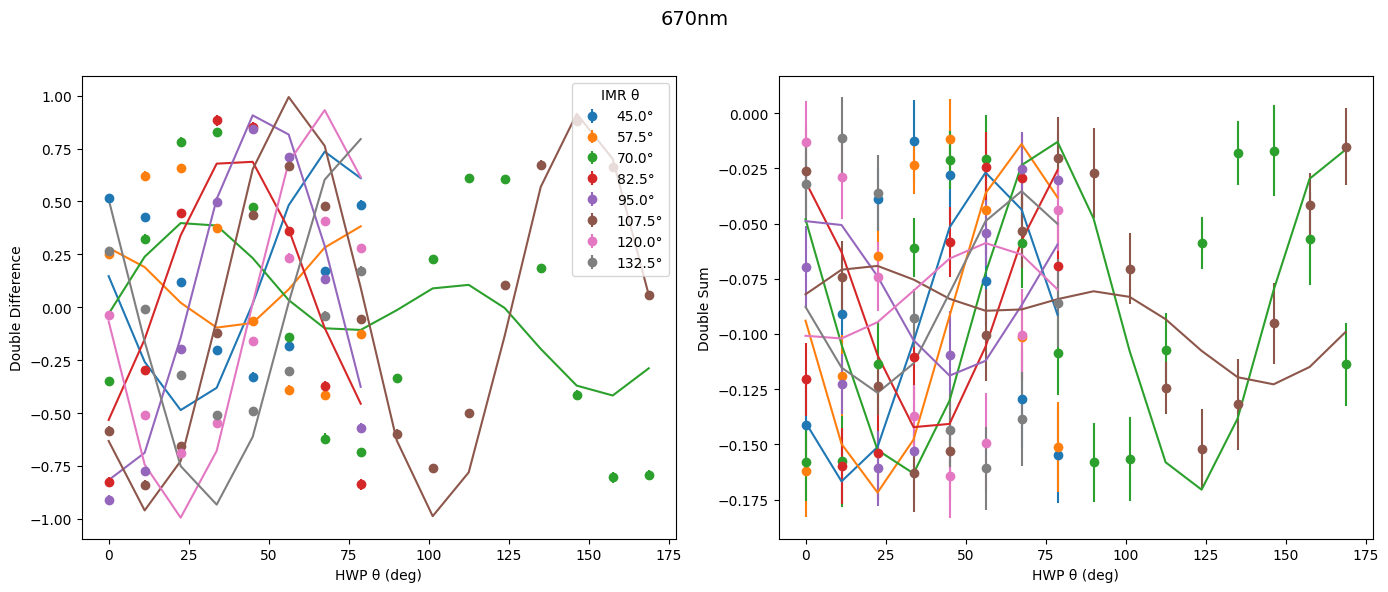

In [13]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': -1.3938711574213065, 'epsilon': 0.005209238748378545, 'theta': -7.445605323627496}, 'flc': {'phi': 2.8701090006190295, 'delta_theta': 4.999999119252516}, 'optics': {'phi': -0.7396375911802608, 'epsilon': 0.002321229389085099, 'theta': 24.716019860602074}, 'image_rotator': {'phi': 2.0201674353850407}, 'hwp': {'phi': 2.9156665754145195, 'delta_theta': -1.2272137742157683}, 'lp': {'theta': -0.10967918339926608}}
Iteration #: 1
logl_value: 75.53159052732929
Best Fit Parameters: [-7.04092873e-01  1.30392836e-02 -2.81592369e+00  3.17100038e+00
 -3.16296636e-01 -7.78660298e-01  2.17906941e-03 -8.43518689e+01
  1.98897114e+00  2.89444837e+00 -1.41792909e+00 -2.91398122e-01]


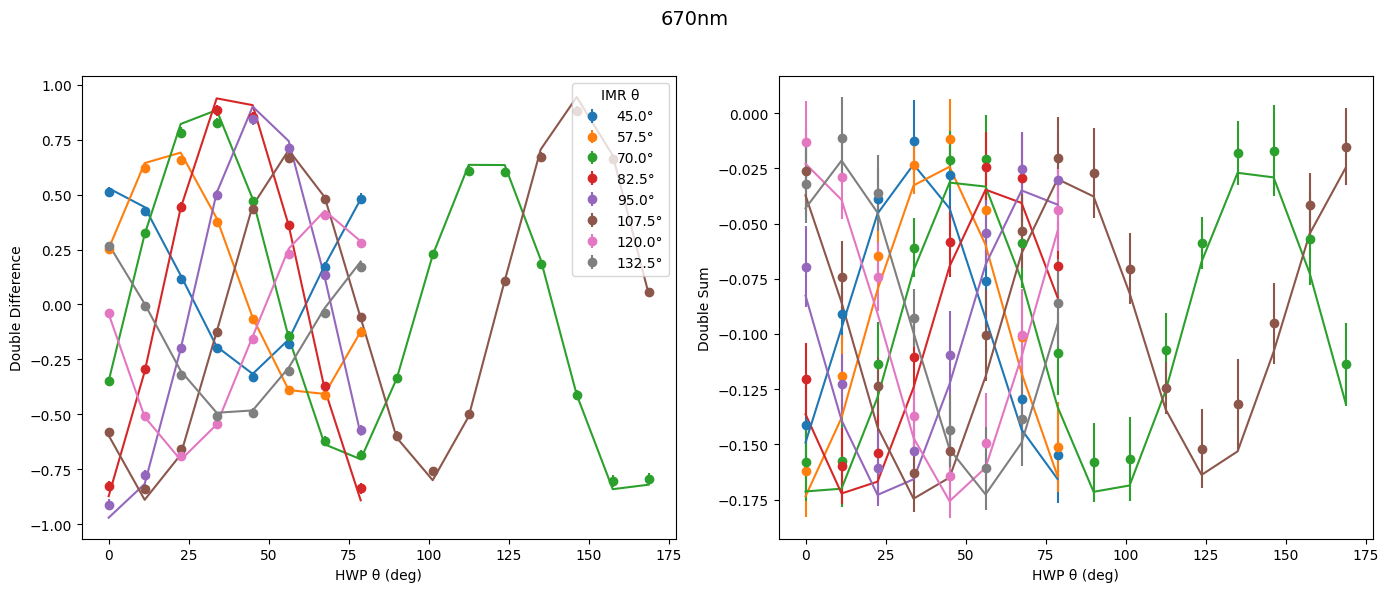

After p0: {'dichroic': {'phi': -0.7040928730495084, 'epsilon': 0.013039283565664764, 'theta': -2.8159236899285034}, 'flc': {'phi': 3.1710003830148104, 'delta_theta': -0.3162966362946805}, 'optics': {'phi': -0.7786602978749237, 'epsilon': 0.0021790694095556815, 'theta': -84.35186891314186}, 'image_rotator': {'phi': 1.9889711434677029}, 'hwp': {'phi': 2.894448372532196, 'delta_theta': -1.4179290945828296}, 'lp': {'theta': -0.29139812184836766}}
Before p0: {'dichroic': {'phi': -0.7040928730495084, 'epsilon': 0.013039283565664764, 'theta': -2.8159236899285034}, 'flc': {'phi': 3.1710003830148104, 'delta_theta': -0.3162966362946805}, 'optics': {'phi': -0.7786602978749237, 'epsilon': 0.0021790694095556815, 'theta': -84.35186891314186}, 'image_rotator': {'phi': 1.9889711434677029}, 'hwp': {'phi': 2.894448372532196, 'delta_theta': -1.4179290945828296}, 'lp': {'theta': -0.29139812184836766}}
Iteration #: 2
logl_value: 52.21628206284535
Best Fit Parameters: [-9.57674369e-01  6.54913330e-04 -6.099

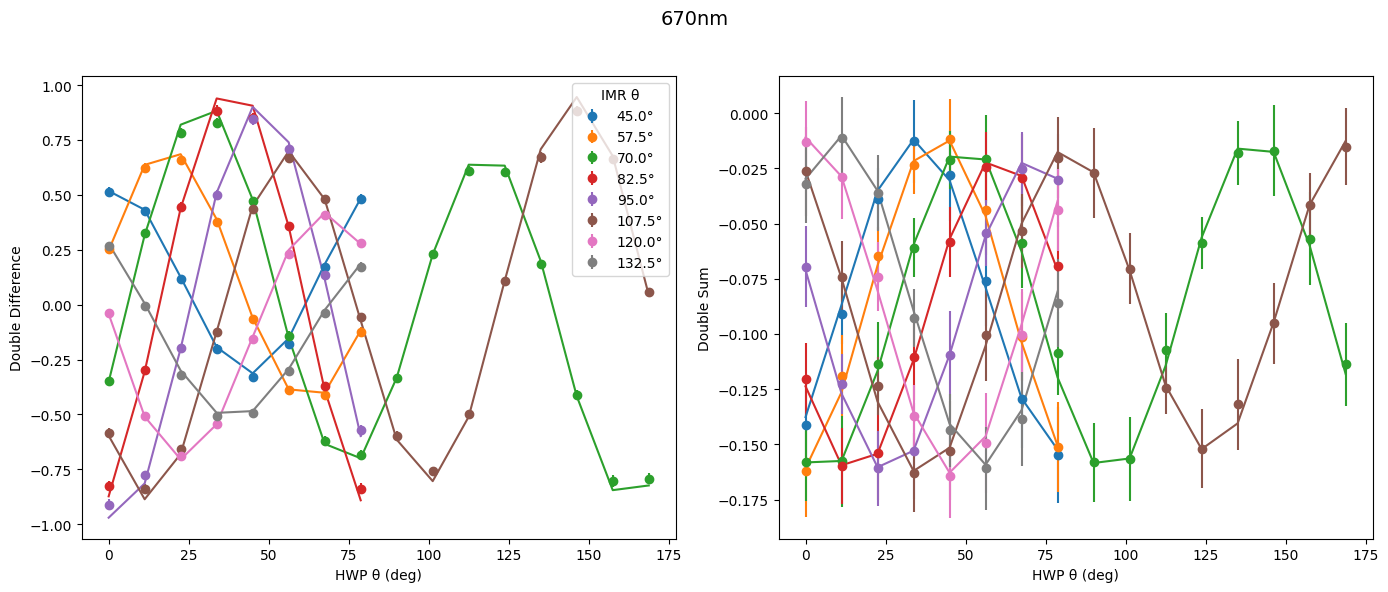

After p0: {'dichroic': {'phi': -0.9576743692088576, 'epsilon': 0.0006549133301166424, 'theta': -6.099976481709916}, 'flc': {'phi': 2.9583240085024975, 'delta_theta': -1.0189425065861997}, 'optics': {'phi': -0.9856558274613374, 'epsilon': 9.333954794276306e-08, 'theta': -82.35064215656219}, 'image_rotator': {'phi': 1.9872258370442877}, 'hwp': {'phi': 2.8925533171577387, 'delta_theta': -0.3758513100771745}, 'lp': {'theta': 1.6003533643660188}}
Before p0: {'dichroic': {'phi': -0.9576743692088576, 'epsilon': 0.0006549133301166424, 'theta': -6.099976481709916}, 'flc': {'phi': 2.9583240085024975, 'delta_theta': -1.0189425065861997}, 'optics': {'phi': -0.9856558274613374, 'epsilon': 9.333954794276306e-08, 'theta': -82.35064215656219}, 'image_rotator': {'phi': 1.9872258370442877}, 'hwp': {'phi': 2.8925533171577387, 'delta_theta': -0.3758513100771745}, 'lp': {'theta': 1.6003533643660188}}
Iteration #: 3
logl_value: 52.21591838096059
Best Fit Parameters: [-1.02002709e+00  6.30473048e-04 -5.95798

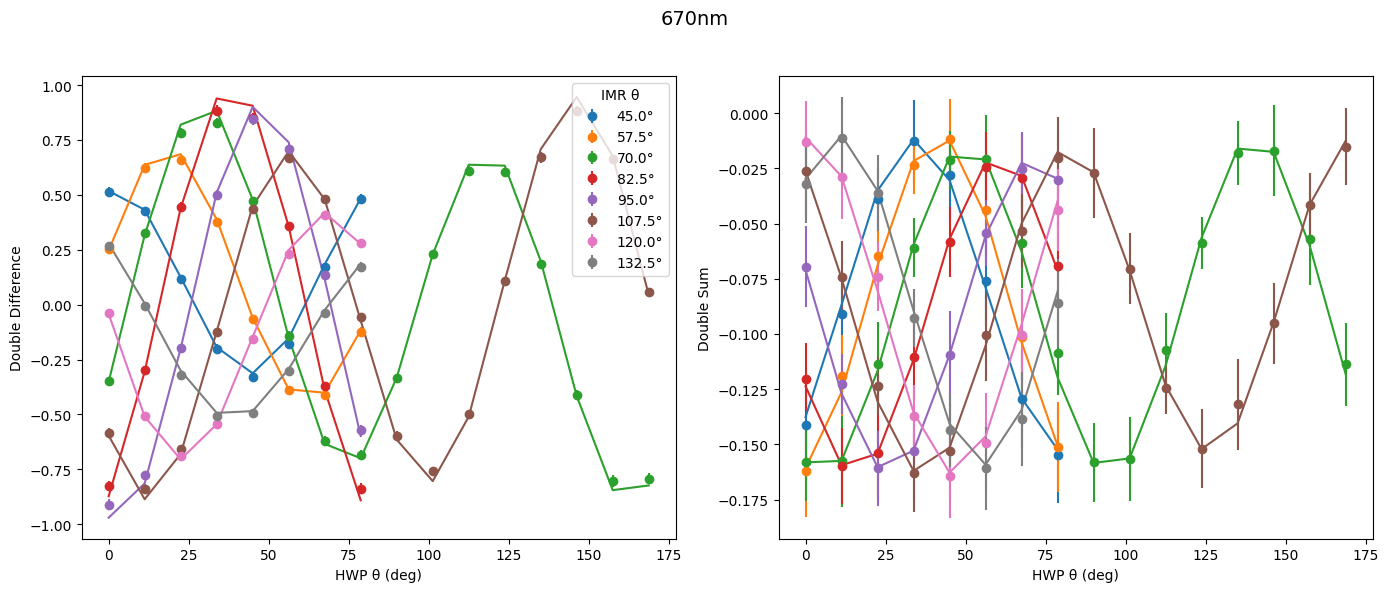

After p0: {'dichroic': {'phi': -1.0200270858837568, 'epsilon': 0.000630473048262204, 'theta': -5.957986673027335}, 'flc': {'phi': 2.9529697789453113, 'delta_theta': -1.1450759443740202}, 'optics': {'phi': -0.9954608732867625, 'epsilon': 4.672336592663584e-09, 'theta': -82.36369791761203}, 'image_rotator': {'phi': 1.9872002029800813}, 'hwp': {'phi': 2.892537351919893, 'delta_theta': -0.3766247822424673}, 'lp': {'theta': 1.5958729360185915}}
Before p0: {'dichroic': {'phi': -1.0200270858837568, 'epsilon': 0.000630473048262204, 'theta': -5.957986673027335}, 'flc': {'phi': 2.9529697789453113, 'delta_theta': -1.1450759443740202}, 'optics': {'phi': -0.9954608732867625, 'epsilon': 4.672336592663584e-09, 'theta': -82.36369791761203}, 'image_rotator': {'phi': 1.9872002029800813}, 'hwp': {'phi': 2.892537351919893, 'delta_theta': -0.3766247822424673}, 'lp': {'theta': 1.5958729360185915}}
Iteration #: 4
logl_value: 52.20953966445417
Best Fit Parameters: [-1.22696908e+00  6.85595368e-04 -7.75384885e

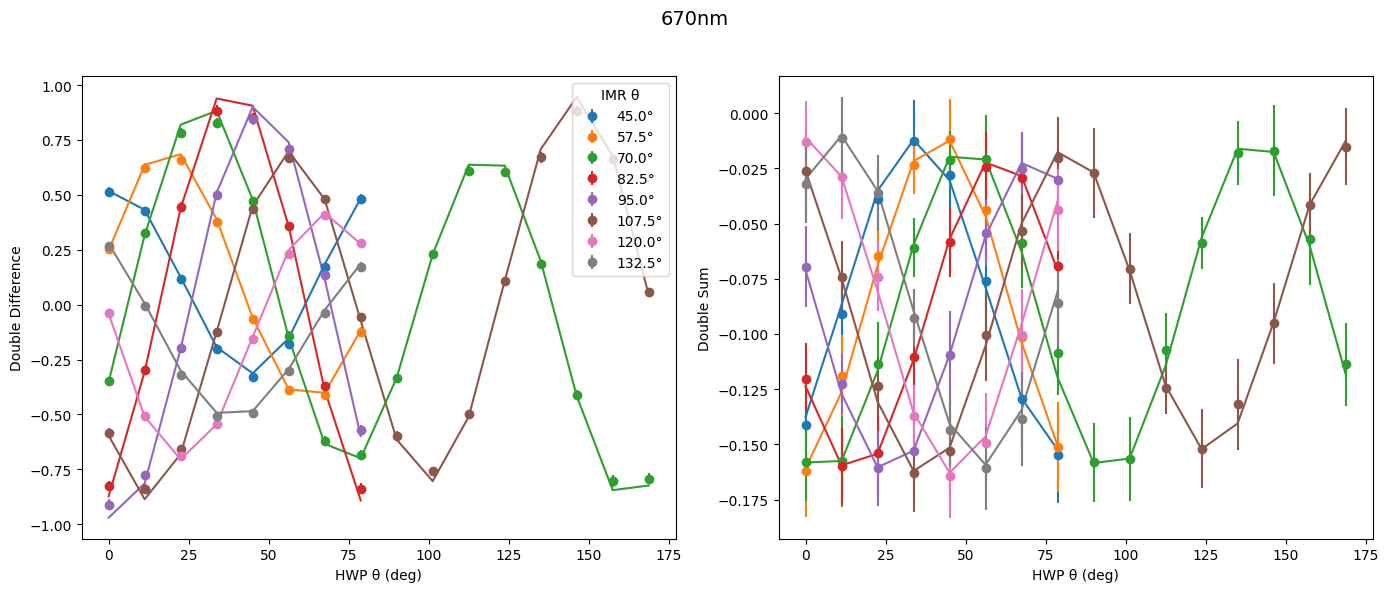

After p0: {'dichroic': {'phi': -1.2269690792567913, 'epsilon': 0.0006855953682100344, 'theta': -7.753848853798482}, 'flc': {'phi': 2.8103740496728133, 'delta_theta': -2.1915573572035427}, 'optics': {'phi': -1.3243714938353728, 'epsilon': 1.2989023847381157e-07, 'theta': -82.83496909923906}, 'image_rotator': {'phi': 1.9872450313920489}, 'hwp': {'phi': 2.892492951400756, 'delta_theta': -0.3687833960882485}, 'lp': {'theta': 1.6130482853226185}}
Before p0: {'dichroic': {'phi': -1.2269690792567913, 'epsilon': 0.0006855953682100344, 'theta': -7.753848853798482}, 'flc': {'phi': 2.8103740496728133, 'delta_theta': -2.1915573572035427}, 'optics': {'phi': -1.3243714938353728, 'epsilon': 1.2989023847381157e-07, 'theta': -82.83496909923906}, 'image_rotator': {'phi': 1.9872450313920489}, 'hwp': {'phi': 2.892492951400756, 'delta_theta': -0.3687833960882485}, 'lp': {'theta': 1.6130482853226185}}
Iteration #: 5
logl_value: 52.20622410239588
Best Fit Parameters: [-1.47578591e+00  6.95545151e-04 -8.26426

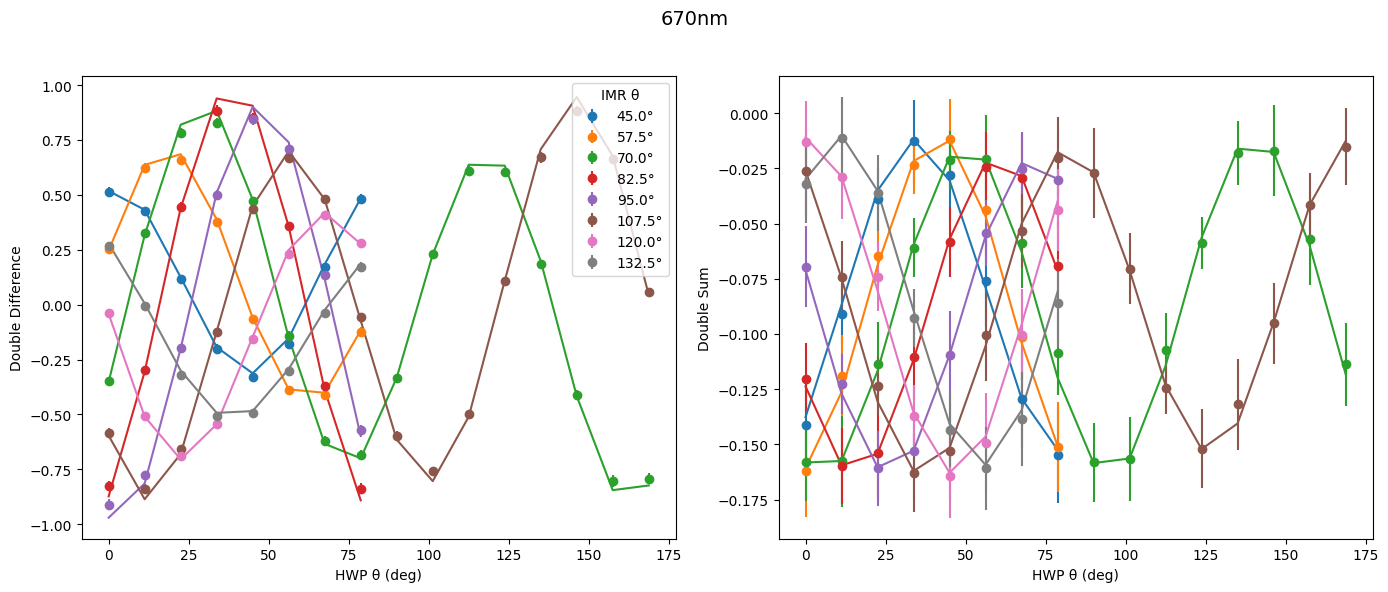

After p0: {'dichroic': {'phi': -1.4757859059900558, 'epsilon': 0.0006955451509981613, 'theta': -8.264260819489861}, 'flc': {'phi': 2.755164046942647, 'delta_theta': -3.3495777063029935}, 'optics': {'phi': -1.4986105709565667, 'epsilon': 1.4286855146761914e-07, 'theta': -83.35473820547733}, 'image_rotator': {'phi': 1.9871759753224252}, 'hwp': {'phi': 2.892608164349646, 'delta_theta': -0.3792750903597423}, 'lp': {'theta': 1.5934423252668284}}
Before p0: {'dichroic': {'phi': -1.4757859059900558, 'epsilon': 0.0006955451509981613, 'theta': -8.264260819489861}, 'flc': {'phi': 2.755164046942647, 'delta_theta': -3.3495777063029935}, 'optics': {'phi': -1.4986105709565667, 'epsilon': 1.4286855146761914e-07, 'theta': -83.35473820547733}, 'image_rotator': {'phi': 1.9871759753224252}, 'hwp': {'phi': 2.892608164349646, 'delta_theta': -0.3792750903597423}, 'lp': {'theta': 1.5934423252668284}}
Iteration #: 6
logl_value: 52.19946170057172
Best Fit Parameters: [-1.38556165e+00  7.91101043e-04 -9.4229631

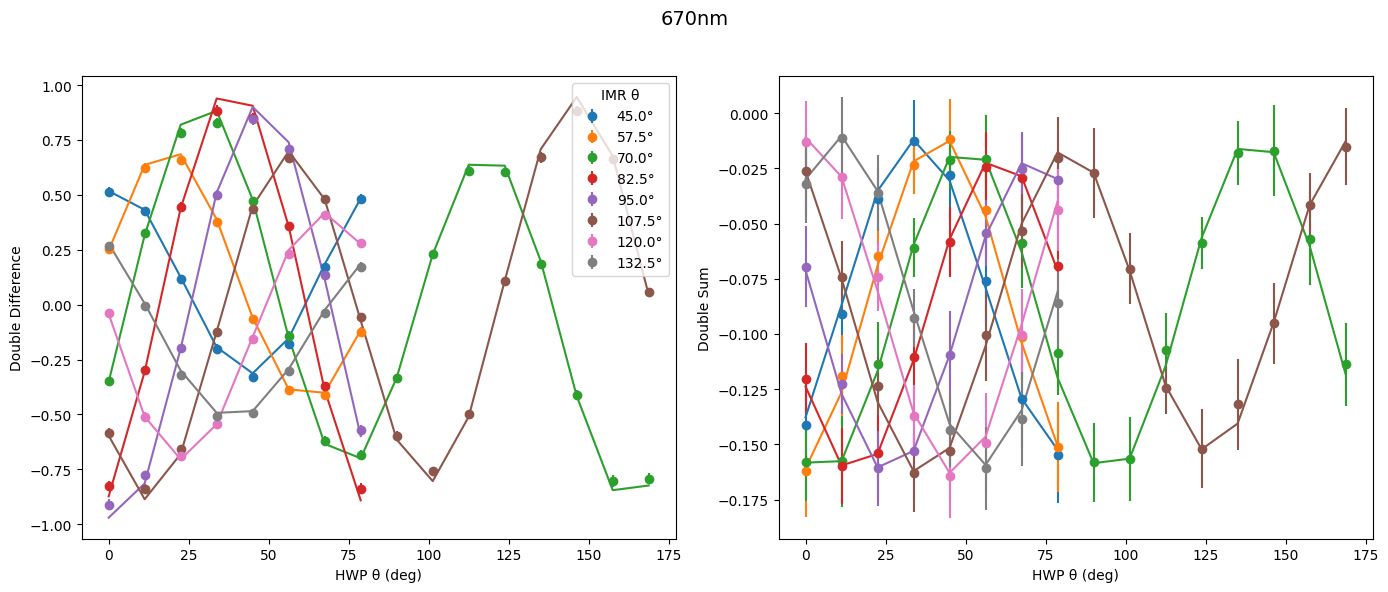

After p0: {'dichroic': {'phi': -1.385561649121883, 'epsilon': 0.0007911010425791713, 'theta': -9.422963134620442}, 'flc': {'phi': 2.67308047896773, 'delta_theta': -3.1428050964555823}, 'optics': {'phi': -1.817731651247334, 'epsilon': 1.985670947701041e-06, 'theta': -83.85041821172902}, 'image_rotator': {'phi': 1.987176304024342}, 'hwp': {'phi': 2.892414027106219, 'delta_theta': -0.36771697585587704}, 'lp': {'theta': 1.6170076696392979}}
Before p0: {'dichroic': {'phi': -1.385561649121883, 'epsilon': 0.0007911010425791713, 'theta': -9.422963134620442}, 'flc': {'phi': 2.67308047896773, 'delta_theta': -3.1428050964555823}, 'optics': {'phi': -1.817731651247334, 'epsilon': 1.985670947701041e-06, 'theta': -83.85041821172902}, 'image_rotator': {'phi': 1.987176304024342}, 'hwp': {'phi': 2.892414027106219, 'delta_theta': -0.36771697585587704}, 'lp': {'theta': 1.6170076696392979}}
Iteration #: 7
logl_value: 52.19383532641377
Best Fit Parameters: [-1.54773739e+00  7.94141002e-04 -9.90728668e+00  2

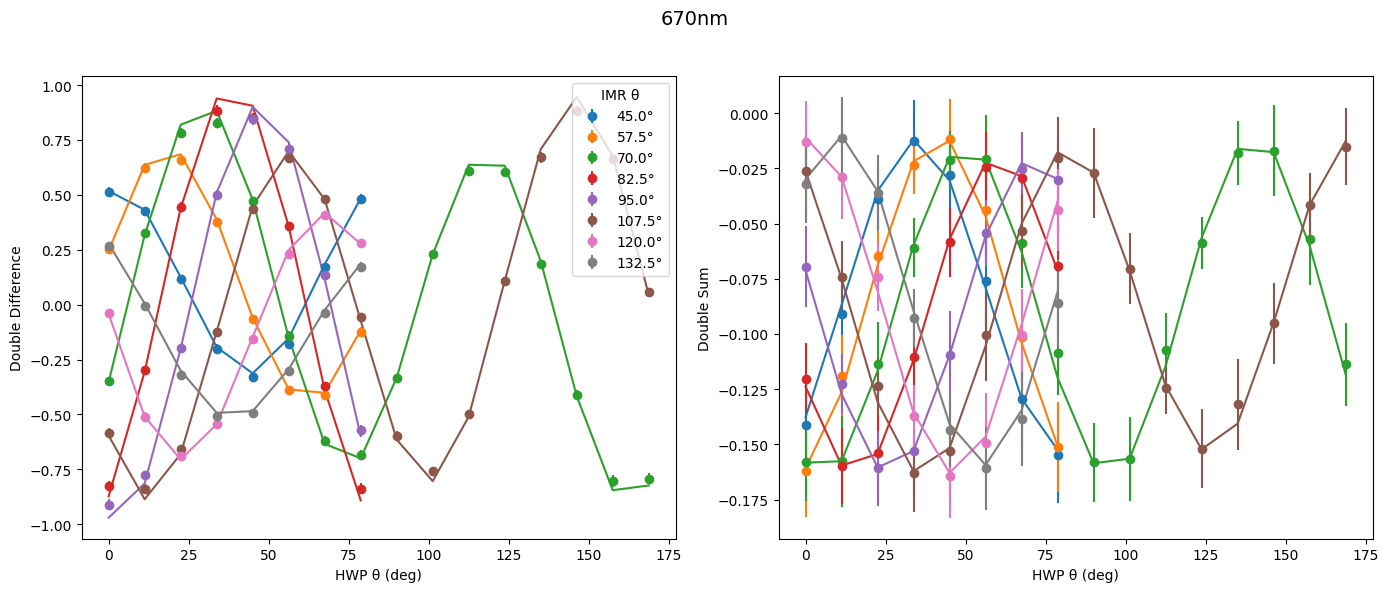

After p0: {'dichroic': {'phi': -1.5477373852013652, 'epsilon': 0.0007941410024532667, 'theta': -9.90728667593289}, 'flc': {'phi': 2.6193094353333866, 'delta_theta': -3.8917058303766154}, 'optics': {'phi': -2.1186439819923466, 'epsilon': 5.813734755407617e-07, 'theta': -84.47790530069935}, 'image_rotator': {'phi': 1.9872538905246646}, 'hwp': {'phi': 2.892485282484094, 'delta_theta': -0.37925758704239165}, 'lp': {'theta': 1.5931832560684798}}
Before p0: {'dichroic': {'phi': -1.5477373852013652, 'epsilon': 0.0007941410024532667, 'theta': -9.90728667593289}, 'flc': {'phi': 2.6193094353333866, 'delta_theta': -3.8917058303766154}, 'optics': {'phi': -2.1186439819923466, 'epsilon': 5.813734755407617e-07, 'theta': -84.47790530069935}, 'image_rotator': {'phi': 1.9872538905246646}, 'hwp': {'phi': 2.892485282484094, 'delta_theta': -0.37925758704239165}, 'lp': {'theta': 1.5931832560684798}}
Iteration #: 8
logl_value: 52.19280108469181
Best Fit Parameters: [-1.65465722e+00  7.96260101e-04 -1.0119081

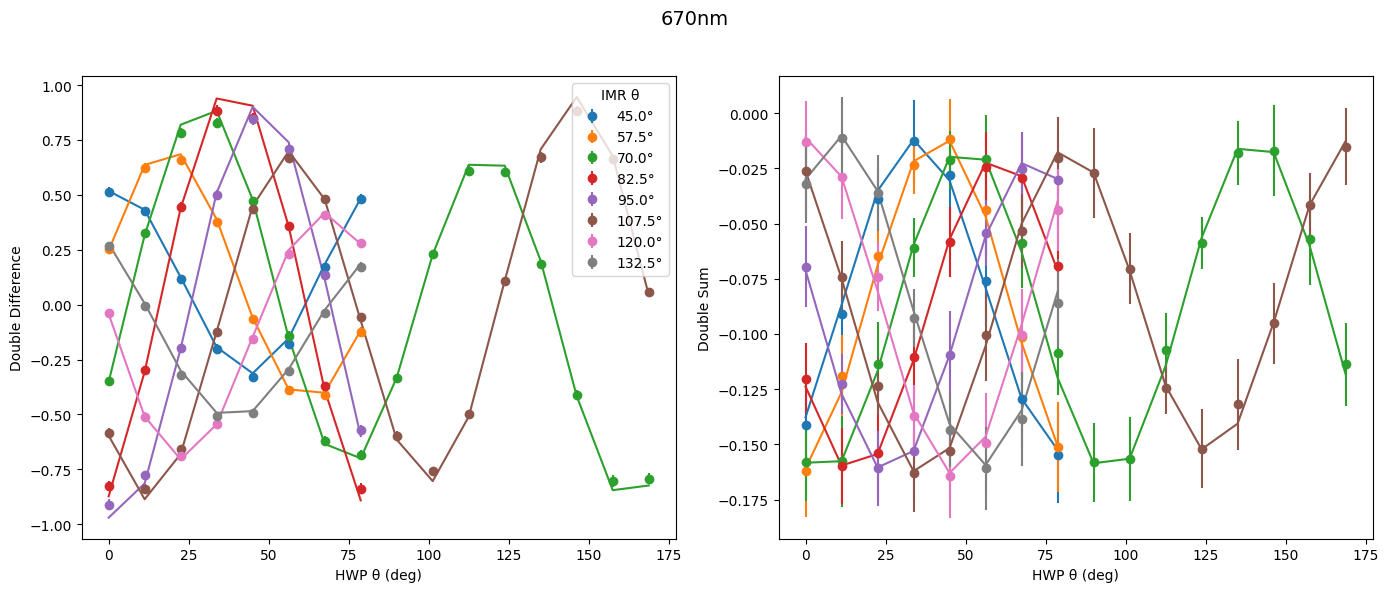

After p0: {'dichroic': {'phi': -1.6546572158994062, 'epsilon': 0.0007962601013824316, 'theta': -10.119081481874751}, 'flc': {'phi': 2.6025528636037976, 'delta_theta': -4.470920128855958}, 'optics': {'phi': -2.251027738159193, 'epsilon': 2.3040116043871142e-08, 'theta': -84.80888361945489}, 'image_rotator': {'phi': 1.9872250184966713}, 'hwp': {'phi': 2.8924702323209974, 'delta_theta': -0.3770865024243466}, 'lp': {'theta': 1.596371238809077}}
Before p0: {'dichroic': {'phi': -1.6546572158994062, 'epsilon': 0.0007962601013824316, 'theta': -10.119081481874751}, 'flc': {'phi': 2.6025528636037976, 'delta_theta': -4.470920128855958}, 'optics': {'phi': -2.251027738159193, 'epsilon': 2.3040116043871142e-08, 'theta': -84.80888361945489}, 'image_rotator': {'phi': 1.9872250184966713}, 'hwp': {'phi': 2.8924702323209974, 'delta_theta': -0.3770865024243466}, 'lp': {'theta': 1.596371238809077}}
Iteration #: 9
logl_value: 52.19278469540726
Best Fit Parameters: [-1.65441401e+00  7.97499199e-04 -1.0118890

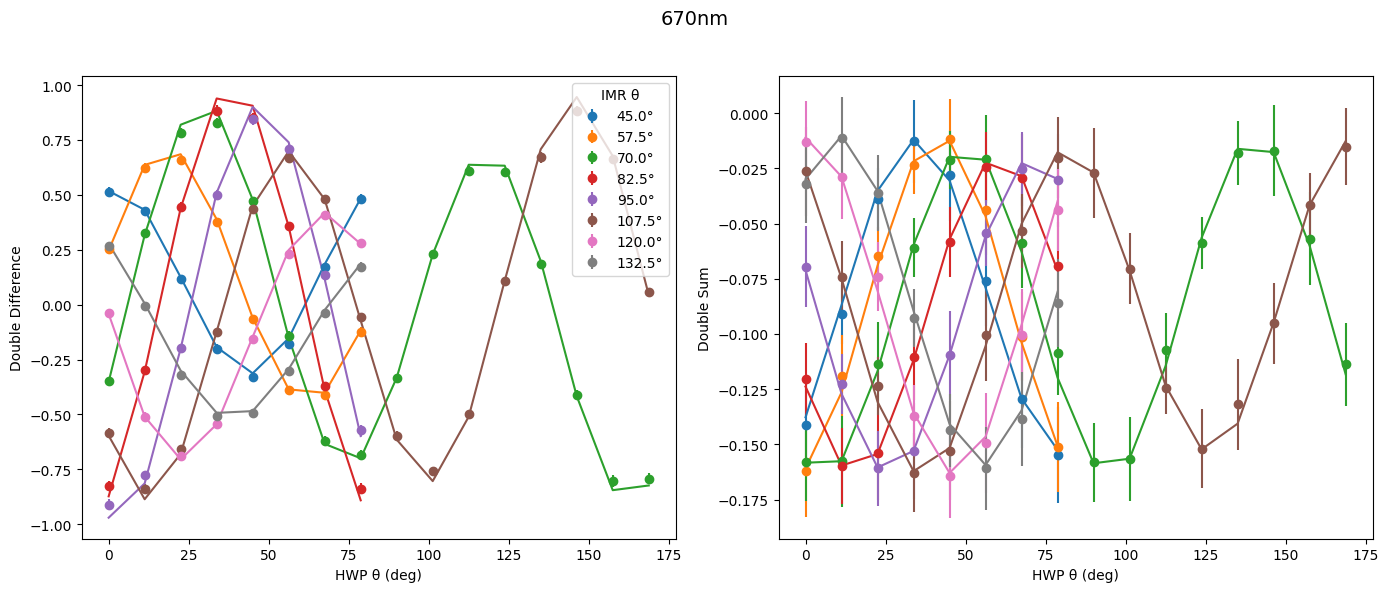

After p0: {'dichroic': {'phi': -1.6544140114797843, 'epsilon': 0.0007974991994298079, 'theta': -10.118890926617595}, 'flc': {'phi': 2.6024981338178383, 'delta_theta': -4.468309071770964}, 'optics': {'phi': -2.251508433668426, 'epsilon': 3.3332237737255684e-11, 'theta': -84.80885981847274}, 'image_rotator': {'phi': 1.9872228745110672}, 'hwp': {'phi': 2.892478969915361, 'delta_theta': -0.3793060701060913}, 'lp': {'theta': 1.5918544134899566}}
Before p0: {'dichroic': {'phi': -1.6544140114797843, 'epsilon': 0.0007974991994298079, 'theta': -10.118890926617595}, 'flc': {'phi': 2.6024981338178383, 'delta_theta': -4.468309071770964}, 'optics': {'phi': -2.251508433668426, 'epsilon': 3.3332237737255684e-11, 'theta': -84.80885981847274}, 'image_rotator': {'phi': 1.9872228745110672}, 'hwp': {'phi': 2.892478969915361, 'delta_theta': -0.3793060701060913}, 'lp': {'theta': 1.5918544134899566}}
Iteration #: 10
logl_value: 52.19278208699313
Best Fit Parameters: [-1.65447319e+00  7.97534059e-04 -1.011923

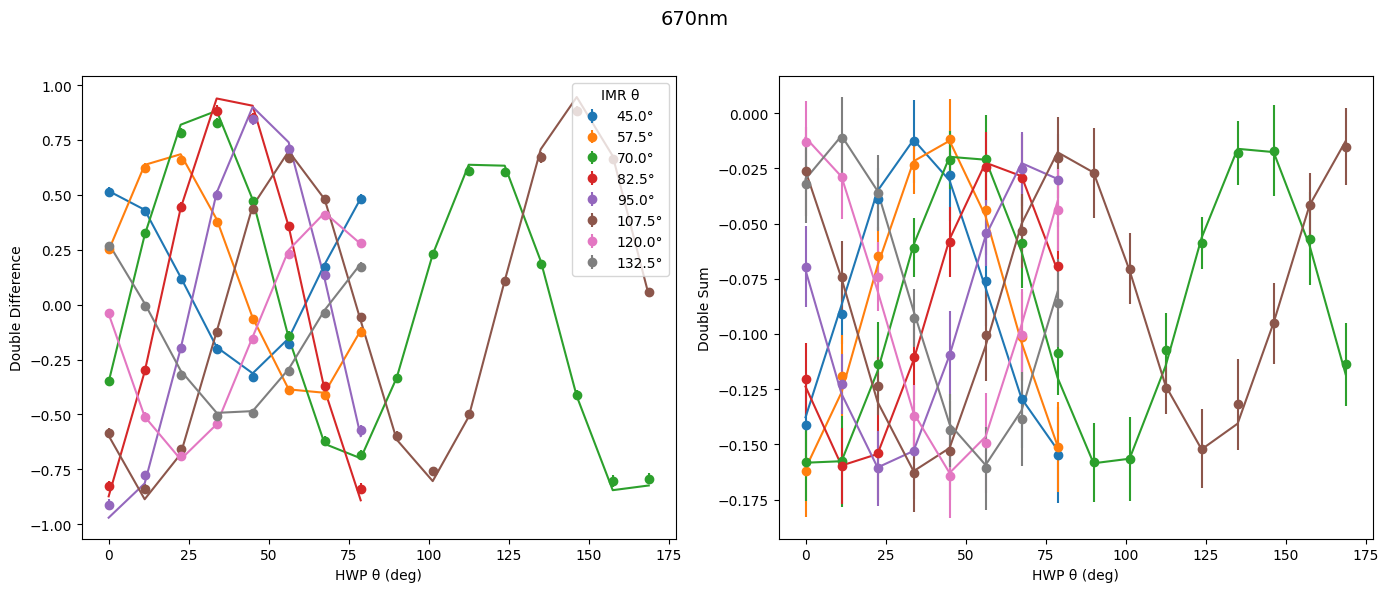

After p0: {'dichroic': {'phi': -1.6544731850131051, 'epsilon': 0.0007975340589118844, 'theta': -10.119239877115909}, 'flc': {'phi': 2.602486594226198, 'delta_theta': -4.468914188801978}, 'optics': {'phi': -2.2515163203050044, 'epsilon': 3.4985639997408175e-11, 'theta': -84.80895753481536}, 'image_rotator': {'phi': 1.9872248873618616}, 'hwp': {'phi': 2.8924753937829775, 'delta_theta': -0.37820223693298394}, 'lp': {'theta': 1.5940756590756804}}
Before p0: {'dichroic': {'phi': -1.6544731850131051, 'epsilon': 0.0007975340589118844, 'theta': -10.119239877115909}, 'flc': {'phi': 2.602486594226198, 'delta_theta': -4.468914188801978}, 'optics': {'phi': -2.2515163203050044, 'epsilon': 3.4985639997408175e-11, 'theta': -84.80895753481536}, 'image_rotator': {'phi': 1.9872248873618616}, 'hwp': {'phi': 2.8924753937829775, 'delta_theta': -0.37820223693298394}, 'lp': {'theta': 1.5940756590756804}}
Iteration #: 11
logl_value: 52.1927820635382
Best Fit Parameters: [-1.65447040e+00  7.97351471e-04 -1.011

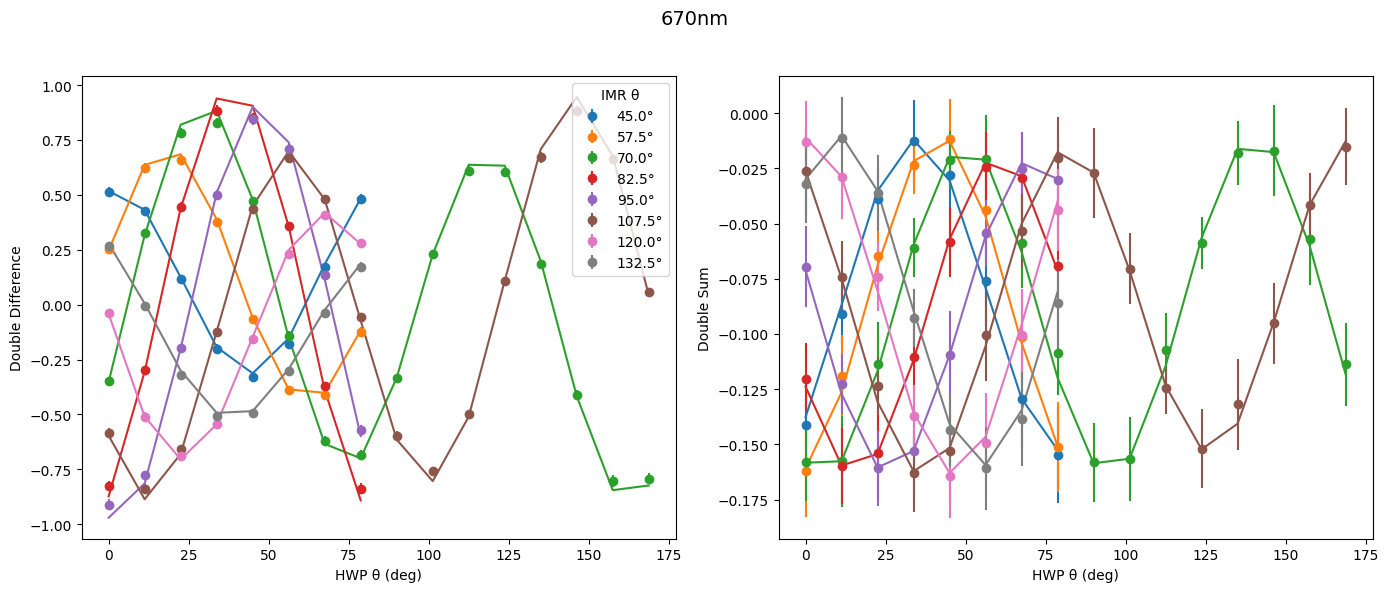

After p0: {'dichroic': {'phi': -1.6544703985432956, 'epsilon': 0.0007973514713801649, 'theta': -10.119243068704488}, 'flc': {'phi': 2.6024854079794872, 'delta_theta': -4.468905959174382}, 'optics': {'phi': -2.2515197364326403, 'epsilon': 3.586431008201075e-11, 'theta': -84.8089520942589}, 'image_rotator': {'phi': 1.987224894827611}, 'hwp': {'phi': 2.8924751546255503, 'delta_theta': -0.3781964525529232}, 'lp': {'theta': 1.59410177270904}}
Before p0: {'dichroic': {'phi': -1.6544703985432956, 'epsilon': 0.0007973514713801649, 'theta': -10.119243068704488}, 'flc': {'phi': 2.6024854079794872, 'delta_theta': -4.468905959174382}, 'optics': {'phi': -2.2515197364326403, 'epsilon': 3.586431008201075e-11, 'theta': -84.8089520942589}, 'image_rotator': {'phi': 1.987224894827611}, 'hwp': {'phi': 2.8924751546255503, 'delta_theta': -0.3781964525529232}, 'lp': {'theta': 1.59410177270904}}
Iteration #: 12
logl_value: 52.19267495734564
Best Fit Parameters: [-1.70188334e+00  7.99898100e-04 -1.02250372e+01

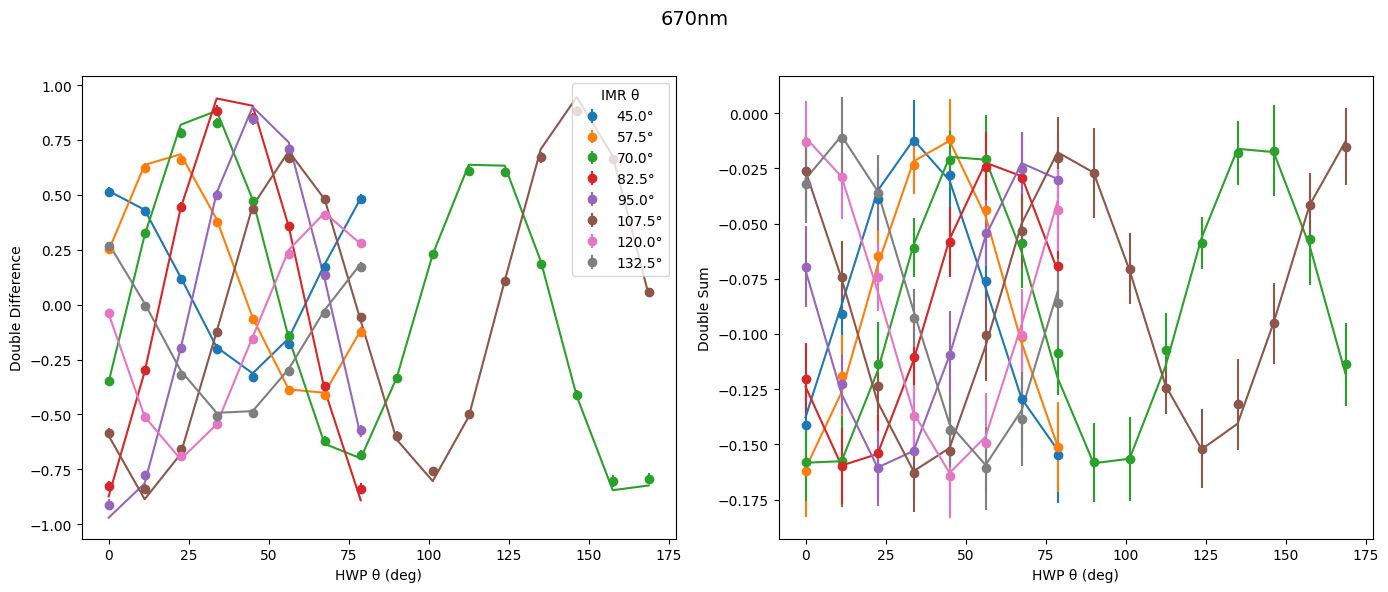

After p0: {'dichroic': {'phi': -1.7018833402448443, 'epsilon': 0.000799898099523387, 'theta': -10.225037186814806}, 'flc': {'phi': 2.5951722679855953, 'delta_theta': -4.723476535399431}, 'optics': {'phi': -2.3225551550273877, 'epsilon': 7.239508491787914e-11, 'theta': -84.9727349695392}, 'image_rotator': {'phi': 1.9872266482038565}, 'hwp': {'phi': 2.8924725280543875, 'delta_theta': -0.3783140181981163}, 'lp': {'theta': 1.5939181272365948}}
Before p0: {'dichroic': {'phi': -1.7018833402448443, 'epsilon': 0.000799898099523387, 'theta': -10.225037186814806}, 'flc': {'phi': 2.5951722679855953, 'delta_theta': -4.723476535399431}, 'optics': {'phi': -2.3225551550273877, 'epsilon': 7.239508491787914e-11, 'theta': -84.9727349695392}, 'image_rotator': {'phi': 1.9872266482038565}, 'hwp': {'phi': 2.8924725280543875, 'delta_theta': -0.3783140181981163}, 'lp': {'theta': 1.5939181272365948}}
Iteration #: 13
logl_value: 52.19237225539602
Best Fit Parameters: [-1.67051451e+00  8.01853932e-04 -1.01095564

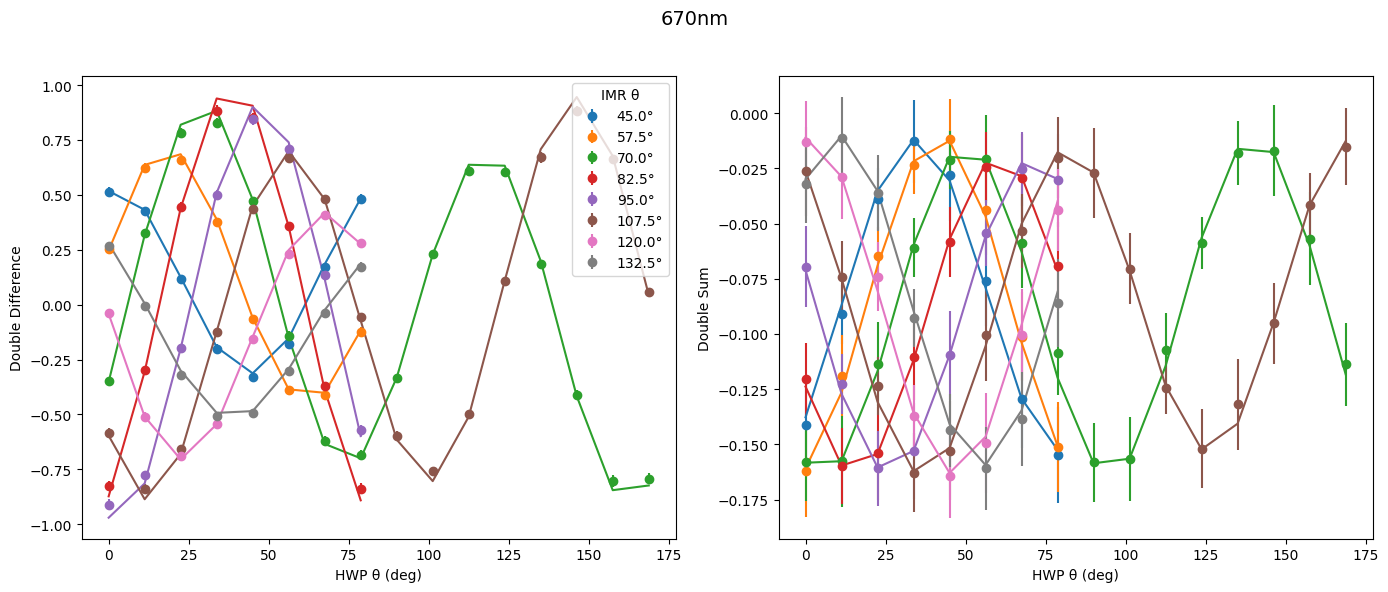

After p0: {'dichroic': {'phi': -1.6705145143637148, 'epsilon': 0.0008018539318405274, 'theta': -10.10955642325823}, 'flc': {'phi': 2.585195165828545, 'delta_theta': -4.183927051219223}, 'optics': {'phi': -2.446110810296024, 'epsilon': 3.998163232974537e-09, 'theta': -84.9852856235283}, 'image_rotator': {'phi': 1.9872307214857923}, 'hwp': {'phi': 2.8924688587388405, 'delta_theta': -0.3777932345938274}, 'lp': {'theta': 1.59494075922346}}
Before p0: {'dichroic': {'phi': -1.6705145143637148, 'epsilon': 0.0008018539318405274, 'theta': -10.10955642325823}, 'flc': {'phi': 2.585195165828545, 'delta_theta': -4.183927051219223}, 'optics': {'phi': -2.446110810296024, 'epsilon': 3.998163232974537e-09, 'theta': -84.9852856235283}, 'image_rotator': {'phi': 1.9872307214857923}, 'hwp': {'phi': 2.8924688587388405, 'delta_theta': -0.3777932345938274}, 'lp': {'theta': 1.59494075922346}}
Iteration #: 14
logl_value: 52.19206811630262
Best Fit Parameters: [-1.57939395e+00  8.00226309e-04 -1.00269228e+01  2.

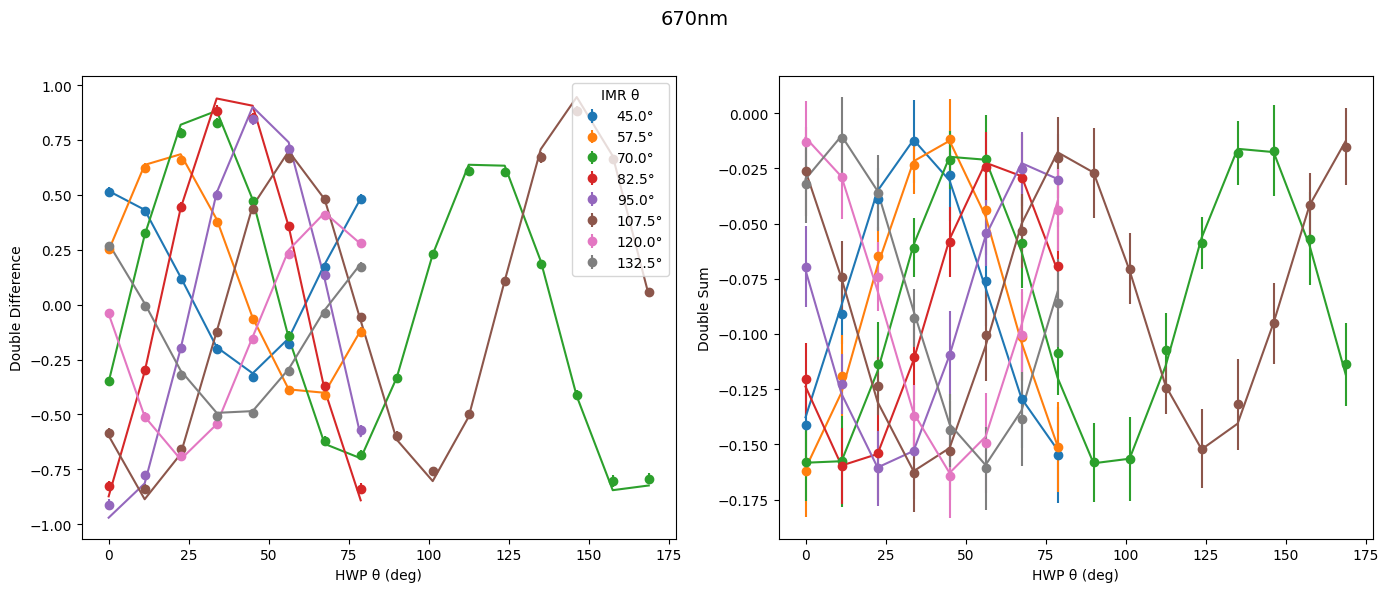

After p0: {'dichroic': {'phi': -1.5793939525732759, 'epsilon': 0.0008002263087087693, 'theta': -10.026922823471843}, 'flc': {'phi': 2.5949946103568795, 'delta_theta': -3.790584447549193}, 'optics': {'phi': -2.321365298081867, 'epsilon': 2.072305713074135e-07, 'theta': -84.72584511669217}, 'image_rotator': {'phi': 1.9872270565148575}, 'hwp': {'phi': 2.892471037194083, 'delta_theta': -0.3767470744705894}, 'lp': {'theta': 1.5968515625412838}}
Before p0: {'dichroic': {'phi': -1.5793939525732759, 'epsilon': 0.0008002263087087693, 'theta': -10.026922823471843}, 'flc': {'phi': 2.5949946103568795, 'delta_theta': -3.790584447549193}, 'optics': {'phi': -2.321365298081867, 'epsilon': 2.072305713074135e-07, 'theta': -84.72584511669217}, 'image_rotator': {'phi': 1.9872270565148575}, 'hwp': {'phi': 2.892471037194083, 'delta_theta': -0.3767470744705894}, 'lp': {'theta': 1.5968515625412838}}
Iteration #: 15
logl_value: 52.1915465890862
Best Fit Parameters: [-1.51470565e+00  8.04202471e-04 -9.94459680e

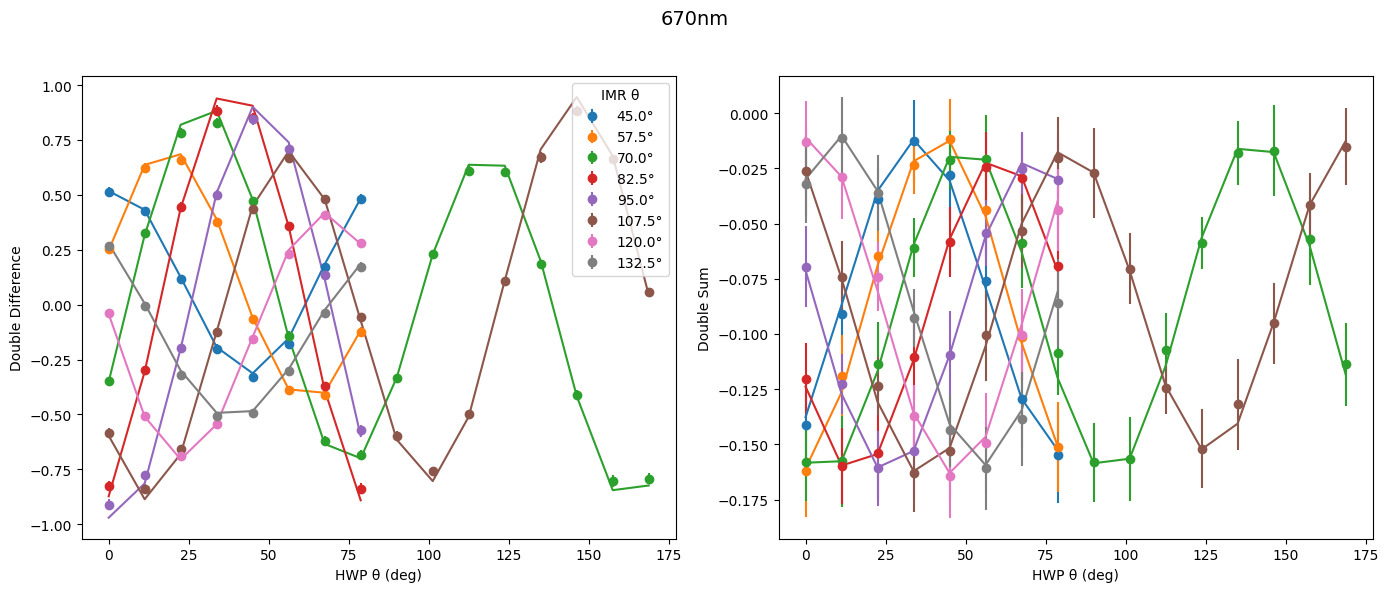

After p0: {'dichroic': {'phi': -1.5147056465426196, 'epsilon': 0.0008042024710420885, 'theta': -9.944596797624136}, 'flc': {'phi': 2.5845349237674053, 'delta_theta': -3.010689012986888}, 'optics': {'phi': -2.4528647384270688, 'epsilon': 2.6926450408814553e-07, 'theta': -84.66647657048486}, 'image_rotator': {'phi': 1.9872292674857048}, 'hwp': {'phi': 2.8924699335009, 'delta_theta': -0.3779547082642065}, 'lp': {'theta': 1.5946964536534978}}
Before p0: {'dichroic': {'phi': -1.5147056465426196, 'epsilon': 0.0008042024710420885, 'theta': -9.944596797624136}, 'flc': {'phi': 2.5845349237674053, 'delta_theta': -3.010689012986888}, 'optics': {'phi': -2.4528647384270688, 'epsilon': 2.6926450408814553e-07, 'theta': -84.66647657048486}, 'image_rotator': {'phi': 1.9872292674857048}, 'hwp': {'phi': 2.8924699335009, 'delta_theta': -0.3779547082642065}, 'lp': {'theta': 1.5946964536534978}}
Iteration #: 16
logl_value: 52.19141682411411
Best Fit Parameters: [-1.51440738e+00  8.06103527e-04 -9.94540698e+

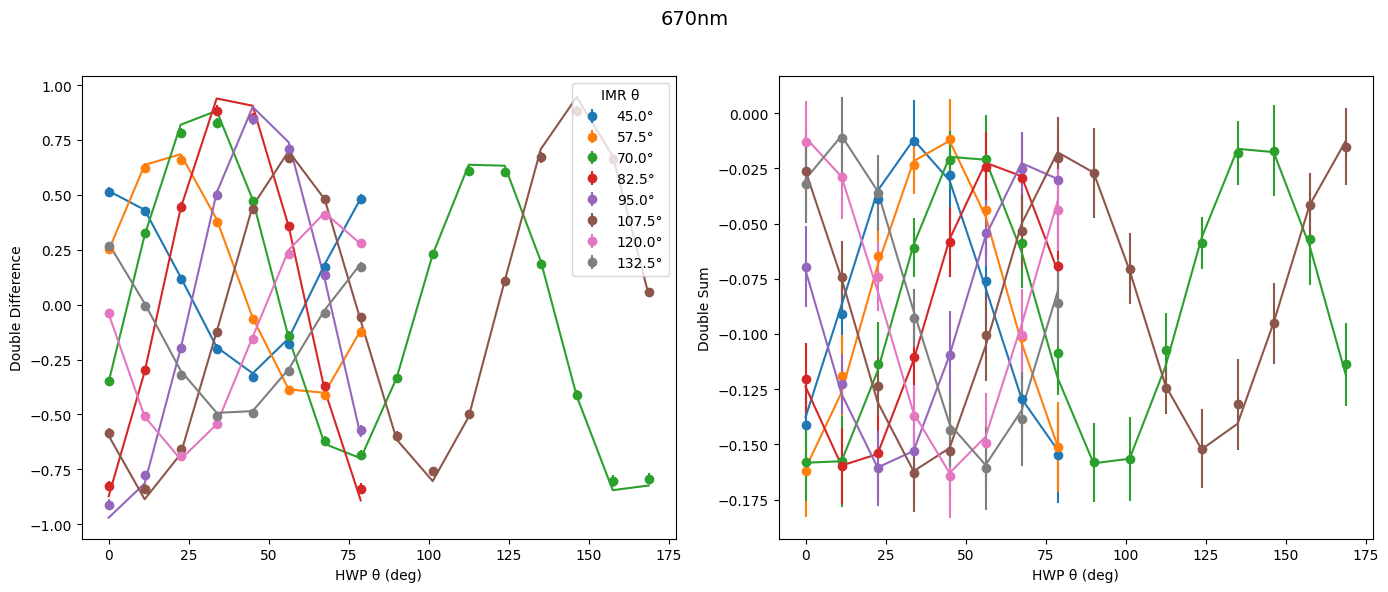

After p0: {'dichroic': {'phi': -1.514407380315935, 'epsilon': 0.0008061035274506708, 'theta': -9.945406979930306}, 'flc': {'phi': 2.5845376545426824, 'delta_theta': -3.009810668020929}, 'optics': {'phi': -2.4525101984950544, 'epsilon': 1.1795413336905978e-10, 'theta': -84.66577175464047}, 'image_rotator': {'phi': 1.987229182355848}, 'hwp': {'phi': 2.892479981687128, 'delta_theta': -0.38006019507716693}, 'lp': {'theta': 1.590120735415102}}
Before p0: {'dichroic': {'phi': -1.514407380315935, 'epsilon': 0.0008061035274506708, 'theta': -9.945406979930306}, 'flc': {'phi': 2.5845376545426824, 'delta_theta': -3.009810668020929}, 'optics': {'phi': -2.4525101984950544, 'epsilon': 1.1795413336905978e-10, 'theta': -84.66577175464047}, 'image_rotator': {'phi': 1.987229182355848}, 'hwp': {'phi': 2.892479981687128, 'delta_theta': -0.38006019507716693}, 'lp': {'theta': 1.590120735415102}}
Iteration #: 17
logl_value: 52.1911317007035
Best Fit Parameters: [-1.46581592e+00  8.05562063e-04 -9.99257551e+0

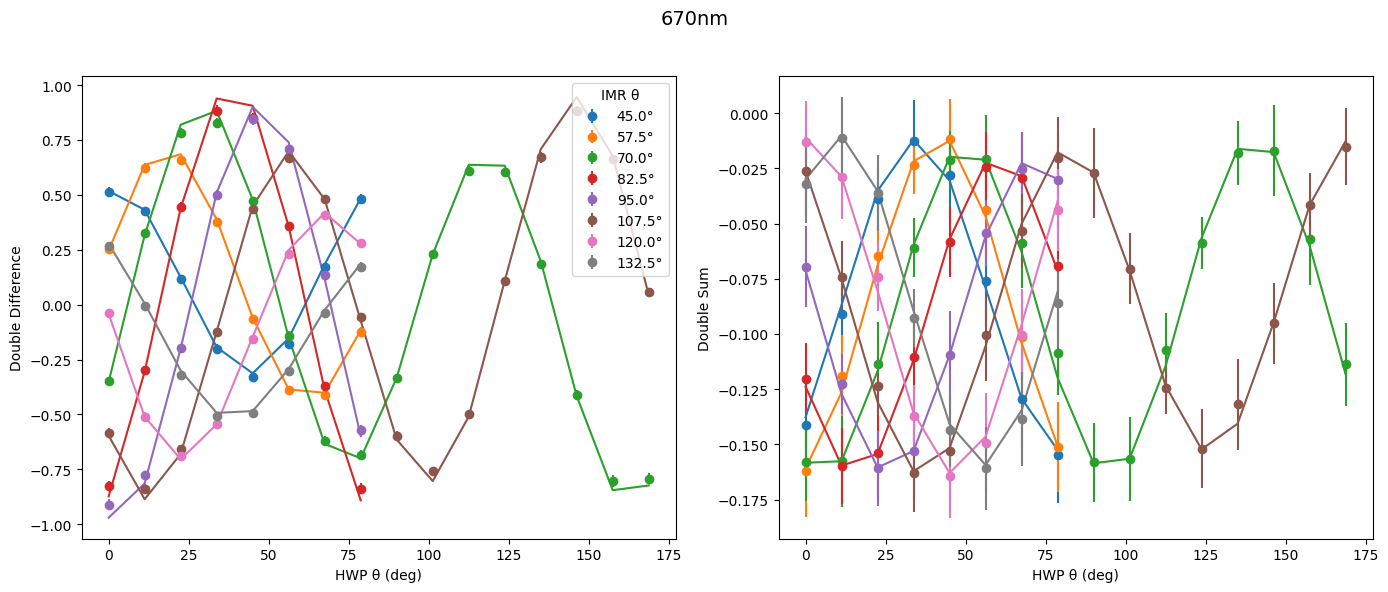

After p0: {'dichroic': {'phi': -1.4658159162146482, 'epsilon': 0.0008055620626848351, 'theta': -9.992575506163657}, 'flc': {'phi': 2.592211747345387, 'delta_theta': -2.971304112690131}, 'optics': {'phi': -2.3489520044139196, 'epsilon': 0.0, 'theta': -84.54309305942755}, 'image_rotator': {'phi': 1.98722705871696}, 'hwp': {'phi': 2.892470132730345, 'delta_theta': -0.3782050672466466}, 'lp': {'theta': 1.594172894792453}}
Before p0: {'dichroic': {'phi': -1.4658159162146482, 'epsilon': 0.0008055620626848351, 'theta': -9.992575506163657}, 'flc': {'phi': 2.592211747345387, 'delta_theta': -2.971304112690131}, 'optics': {'phi': -2.3489520044139196, 'epsilon': 0.0, 'theta': -84.54309305942755}, 'image_rotator': {'phi': 1.98722705871696}, 'hwp': {'phi': 2.892470132730345, 'delta_theta': -0.3782050672466466}, 'lp': {'theta': 1.594172894792453}}
Iteration #: 18
logl_value: 52.19113156238842
Best Fit Parameters: [-1.46581168e+00  8.05824278e-04 -9.99257289e+00  2.59221033e+00
 -2.97119840e+00 -2.348

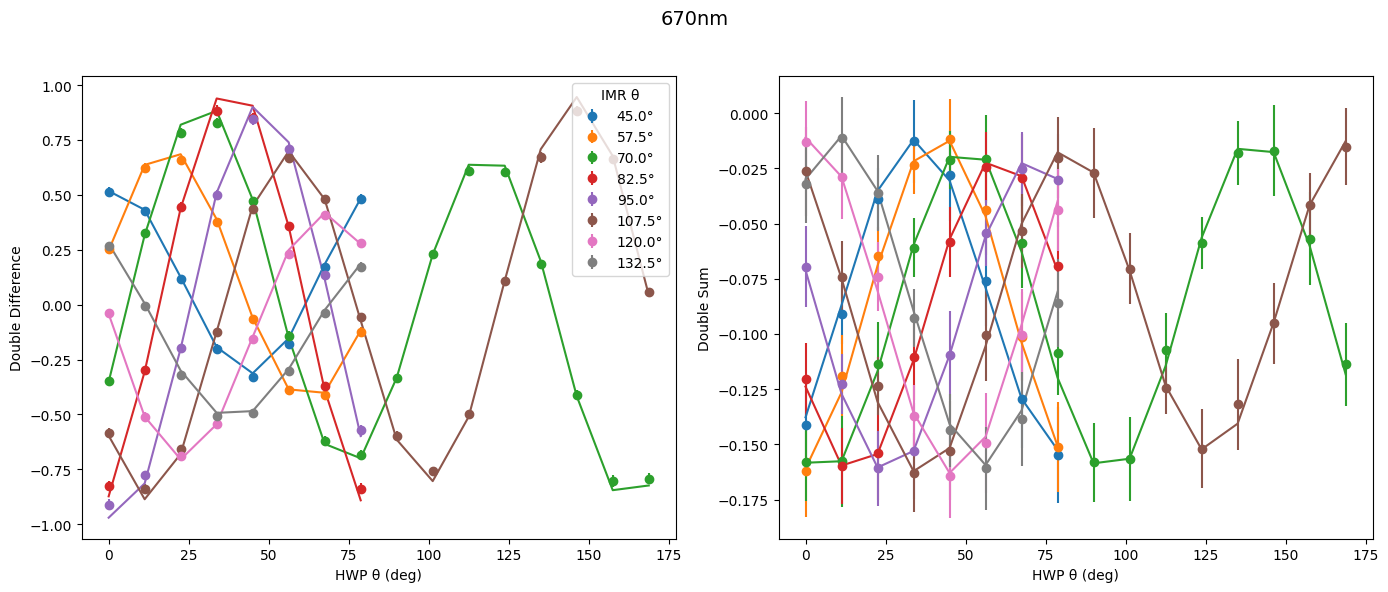

After p0: {'dichroic': {'phi': -1.465811679858802, 'epsilon': 0.0008058242782782701, 'theta': -9.9925728878322}, 'flc': {'phi': 2.5922103331295645, 'delta_theta': -2.97119839602865}, 'optics': {'phi': -2.348982085866009, 'epsilon': 3.32360194532969e-11, 'theta': -84.54310297138744}, 'image_rotator': {'phi': 1.9872283062758231}, 'hwp': {'phi': 2.8924701756779916, 'delta_theta': -0.3781236179922104}, 'lp': {'theta': 1.594313213832089}}
Before p0: {'dichroic': {'phi': -1.465811679858802, 'epsilon': 0.0008058242782782701, 'theta': -9.9925728878322}, 'flc': {'phi': 2.5922103331295645, 'delta_theta': -2.97119839602865}, 'optics': {'phi': -2.348982085866009, 'epsilon': 3.32360194532969e-11, 'theta': -84.54310297138744}, 'image_rotator': {'phi': 1.9872283062758231}, 'hwp': {'phi': 2.8924701756779916, 'delta_theta': -0.3781236179922104}, 'lp': {'theta': 1.594313213832089}}
Iteration #: 19
logl_value: 52.19113152844469
Best Fit Parameters: [-1.46582620e+00  8.06253095e-04 -9.99255955e+00  2.5922

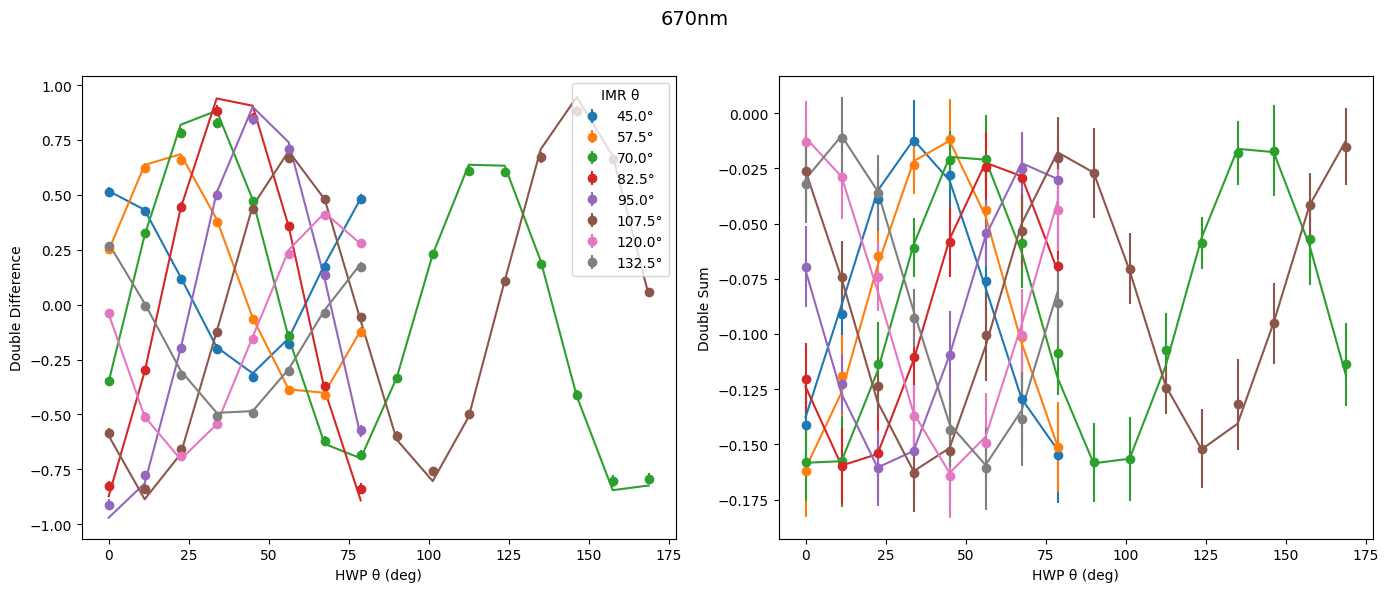

After p0: {'dichroic': {'phi': -1.4658261992122, 'epsilon': 0.0008062530954465951, 'theta': -9.992559547591181}, 'flc': {'phi': 2.592204191291314, 'delta_theta': -2.9711838885107}, 'optics': {'phi': -2.349026035177032, 'epsilon': 3.40557986574739e-11, 'theta': -84.54312644050897}, 'image_rotator': {'phi': 1.9872287110304132}, 'hwp': {'phi': 2.892469474165062, 'delta_theta': -0.37817821216205594}, 'lp': {'theta': 1.5942715562371383}}
Before p0: {'dichroic': {'phi': -1.4658261992122, 'epsilon': 0.0008062530954465951, 'theta': -9.992559547591181}, 'flc': {'phi': 2.592204191291314, 'delta_theta': -2.9711838885107}, 'optics': {'phi': -2.349026035177032, 'epsilon': 3.40557986574739e-11, 'theta': -84.54312644050897}, 'image_rotator': {'phi': 1.9872287110304132}, 'hwp': {'phi': 2.892469474165062, 'delta_theta': -0.37817821216205594}, 'lp': {'theta': 1.5942715562371383}}
Iteration #: 20
logl_value: 52.19113146634679
Best Fit Parameters: [-1.46582434e+00  8.05881930e-04 -9.99255318e+00  2.592204

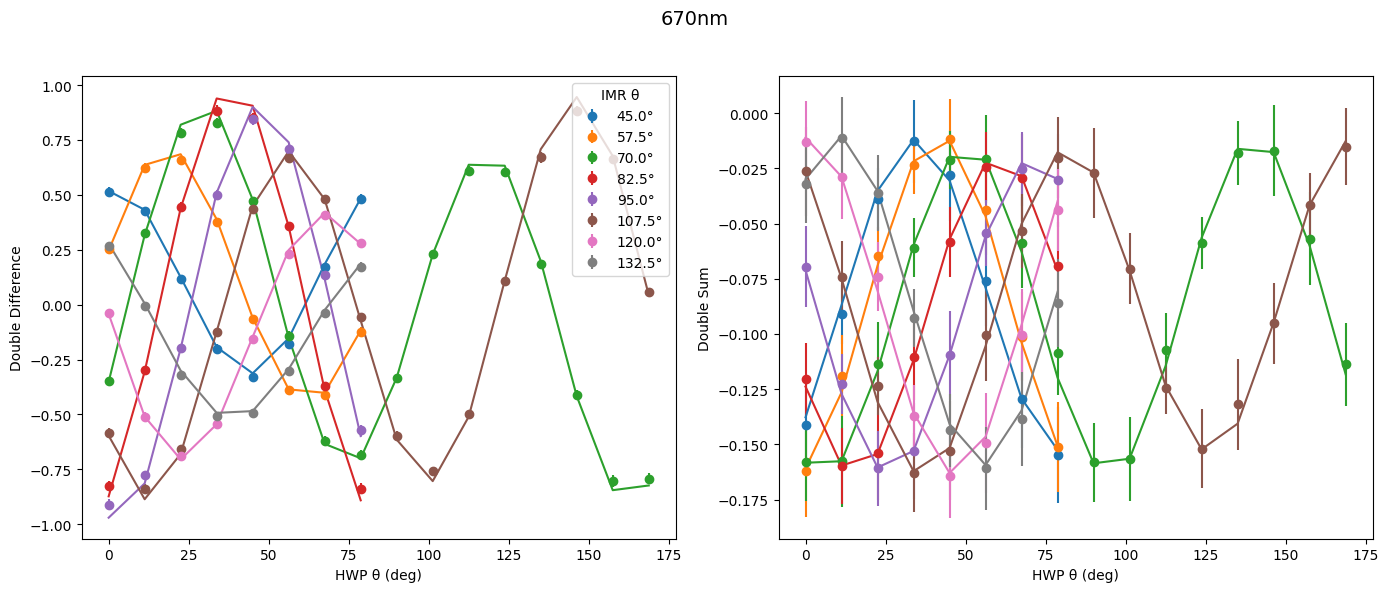

After p0: {'dichroic': {'phi': -1.4658243351462894, 'epsilon': 0.0008058819296768327, 'theta': -9.99255318379052}, 'flc': {'phi': 2.592204266745137, 'delta_theta': -2.9711582271235684}, 'optics': {'phi': -2.3490357640252313, 'epsilon': 3.4915668018190594e-11, 'theta': -84.54312694006632}, 'image_rotator': {'phi': 1.9872289024212235}, 'hwp': {'phi': 2.892469986302178, 'delta_theta': -0.3781580316616366}, 'lp': {'theta': 1.594306840295456}}
Before p0: {'dichroic': {'phi': -1.4658243351462894, 'epsilon': 0.0008058819296768327, 'theta': -9.99255318379052}, 'flc': {'phi': 2.592204266745137, 'delta_theta': -2.9711582271235684}, 'optics': {'phi': -2.3490357640252313, 'epsilon': 3.4915668018190594e-11, 'theta': -84.54312694006632}, 'image_rotator': {'phi': 1.9872289024212235}, 'hwp': {'phi': 2.892469986302178, 'delta_theta': -0.3781580316616366}, 'lp': {'theta': 1.594306840295456}}
Iteration #: 21
logl_value: 52.19113139092348
Best Fit Parameters: [-1.46583781e+00  8.06325047e-04 -9.99256020e+

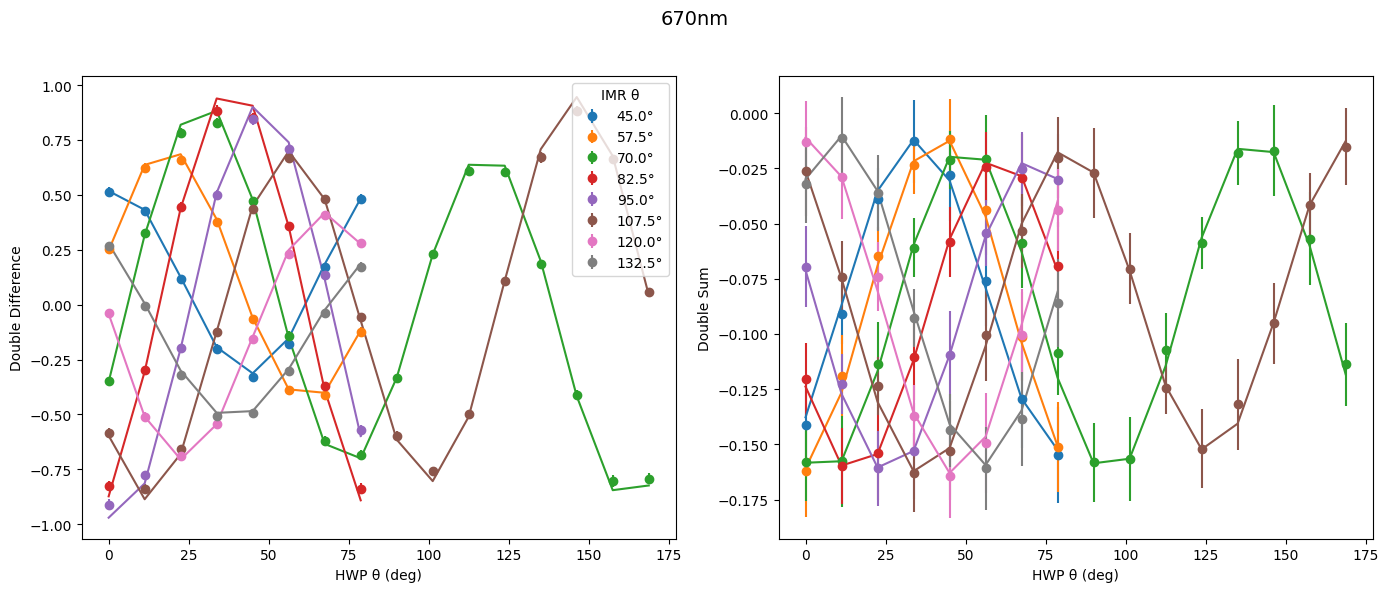

After p0: {'dichroic': {'phi': -1.4658378149944986, 'epsilon': 0.0008063250471491089, 'theta': -9.99256020028243}, 'flc': {'phi': 2.5921979721833326, 'delta_theta': -2.9711007276410095}, 'optics': {'phi': -2.3491000082829503, 'epsilon': 3.5614051473140137e-11, 'theta': -84.5431975875963}, 'image_rotator': {'phi': 1.9872279801587105}, 'hwp': {'phi': 2.8924701646518507, 'delta_theta': -0.3782660773561779}, 'lp': {'theta': 1.5940791911438617}}
Before p0: {'dichroic': {'phi': -1.4658378149944986, 'epsilon': 0.0008063250471491089, 'theta': -9.99256020028243}, 'flc': {'phi': 2.5921979721833326, 'delta_theta': -2.9711007276410095}, 'optics': {'phi': -2.3491000082829503, 'epsilon': 3.5614051473140137e-11, 'theta': -84.5431975875963}, 'image_rotator': {'phi': 1.9872279801587105}, 'hwp': {'phi': 2.8924701646518507, 'delta_theta': -0.3782660773561779}, 'lp': {'theta': 1.5940791911438617}}
Iteration #: 22
logl_value: 52.19113138827869
Best Fit Parameters: [-1.46585398e+00  8.06178673e-04 -9.992536

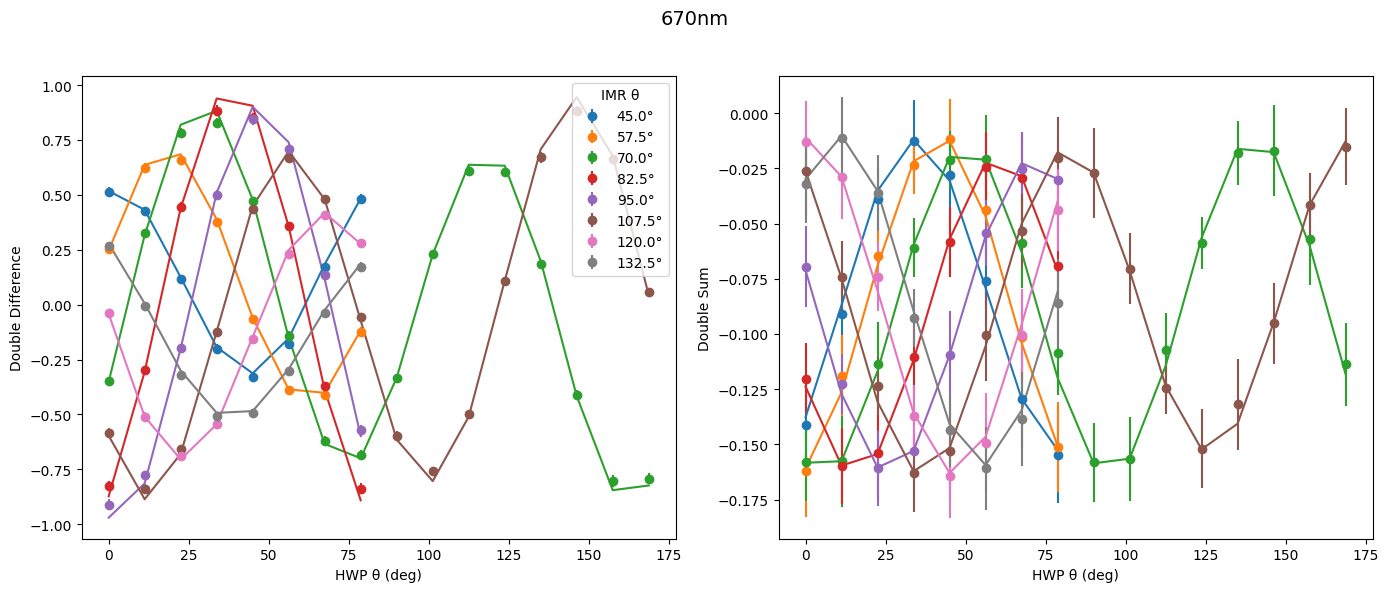

After p0: {'dichroic': {'phi': -1.4658539799206316, 'epsilon': 0.0008061786726285447, 'theta': -9.992536589589147}, 'flc': {'phi': 2.5921945049946196, 'delta_theta': -2.9710851137446364}, 'optics': {'phi': -2.3491481436071617, 'epsilon': 3.650643097586728e-11, 'theta': -84.54325219327208}, 'image_rotator': {'phi': 1.9872276443276837}, 'hwp': {'phi': 2.892469003325155, 'delta_theta': -0.3782951315174645}, 'lp': {'theta': 1.594029855504663}}
Before p0: {'dichroic': {'phi': -1.4658539799206316, 'epsilon': 0.0008061786726285447, 'theta': -9.992536589589147}, 'flc': {'phi': 2.5921945049946196, 'delta_theta': -2.9710851137446364}, 'optics': {'phi': -2.3491481436071617, 'epsilon': 3.650643097586728e-11, 'theta': -84.54325219327208}, 'image_rotator': {'phi': 1.9872276443276837}, 'hwp': {'phi': 2.892469003325155, 'delta_theta': -0.3782951315174645}, 'lp': {'theta': 1.594029855504663}}
Iteration #: 23
logl_value: 52.191131359193335
Best Fit Parameters: [-1.46587208e+00  8.06102295e-04 -9.9925306

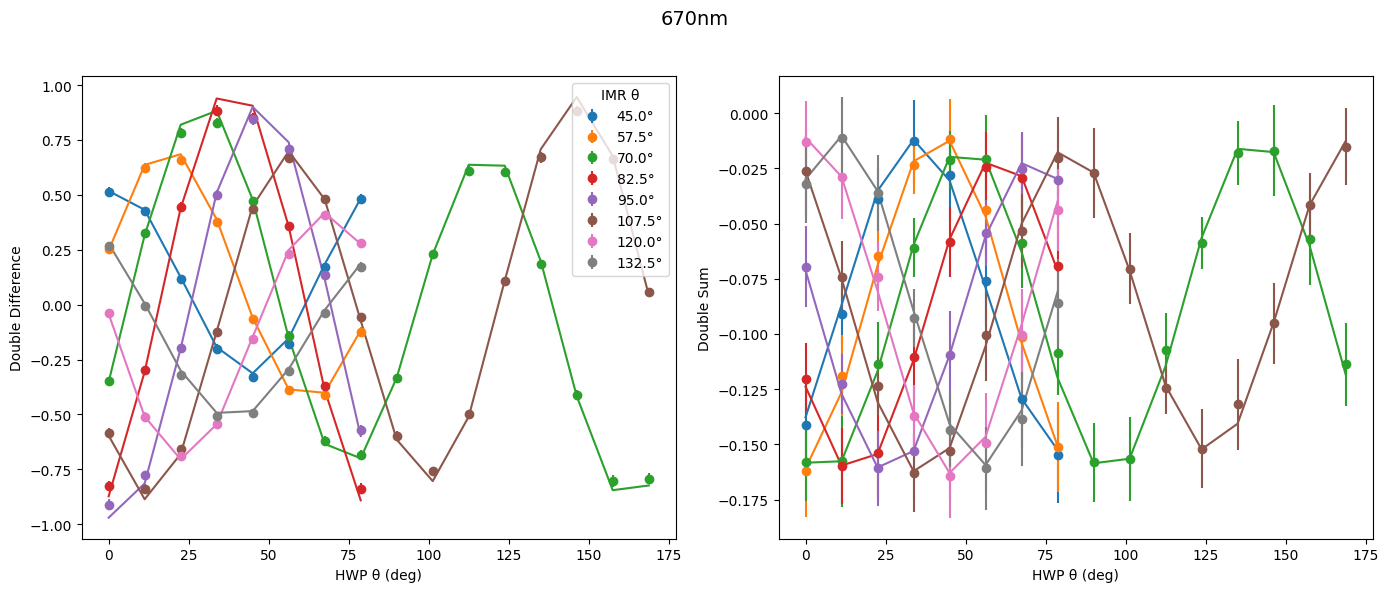

After p0: {'dichroic': {'phi': -1.4658720833755479, 'epsilon': 0.0008061022947815253, 'theta': -9.99253061356653}, 'flc': {'phi': 2.5921892012526113, 'delta_theta': -2.9710796059868176}, 'optics': {'phi': -2.3492072208595722, 'epsilon': 3.741959883656832e-11, 'theta': -84.54332118603719}, 'image_rotator': {'phi': 1.9872282032919117}, 'hwp': {'phi': 2.892469767450489, 'delta_theta': -0.37831644143313026}, 'lp': {'theta': 1.5939941645365467}}
Before p0: {'dichroic': {'phi': -1.4658720833755479, 'epsilon': 0.0008061022947815253, 'theta': -9.99253061356653}, 'flc': {'phi': 2.5921892012526113, 'delta_theta': -2.9710796059868176}, 'optics': {'phi': -2.3492072208595722, 'epsilon': 3.741959883656832e-11, 'theta': -84.54332118603719}, 'image_rotator': {'phi': 1.9872282032919117}, 'hwp': {'phi': 2.892469767450489, 'delta_theta': -0.37831644143313026}, 'lp': {'theta': 1.5939941645365467}}
Iteration #: 24
logl_value: 52.19113131673862
Best Fit Parameters: [-1.46588229e+00  8.05857576e-04 -9.992498

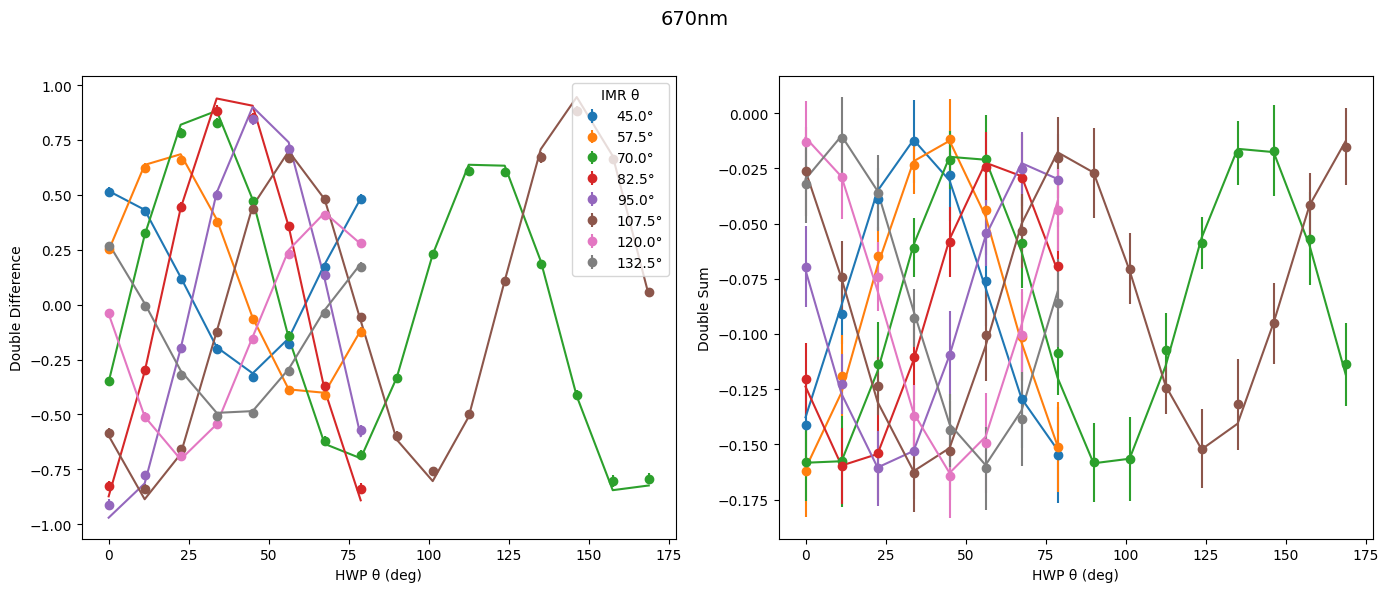

After p0: {'dichroic': {'phi': -1.4658822911777252, 'epsilon': 0.0008058575757133634, 'theta': -9.992498636464362}, 'flc': {'phi': 2.5921857692091597, 'delta_theta': -2.9710337570460874}, 'optics': {'phi': -2.3492438834666878, 'epsilon': 3.8359708549663724e-11, 'theta': -84.54335206932538}, 'image_rotator': {'phi': 1.9872284746275772}, 'hwp': {'phi': 2.8924701556290797, 'delta_theta': -0.37835349645182514}, 'lp': {'theta': 1.5939245316063304}}
Before p0: {'dichroic': {'phi': -1.4658822911777252, 'epsilon': 0.0008058575757133634, 'theta': -9.992498636464362}, 'flc': {'phi': 2.5921857692091597, 'delta_theta': -2.9710337570460874}, 'optics': {'phi': -2.3492438834666878, 'epsilon': 3.8359708549663724e-11, 'theta': -84.54335206932538}, 'image_rotator': {'phi': 1.9872284746275772}, 'hwp': {'phi': 2.8924701556290797, 'delta_theta': -0.37835349645182514}, 'lp': {'theta': 1.5939245316063304}}
Iteration #: 25
logl_value: 52.19113128731909
Best Fit Parameters: [-1.46588703e+00  8.05982695e-04 -9.

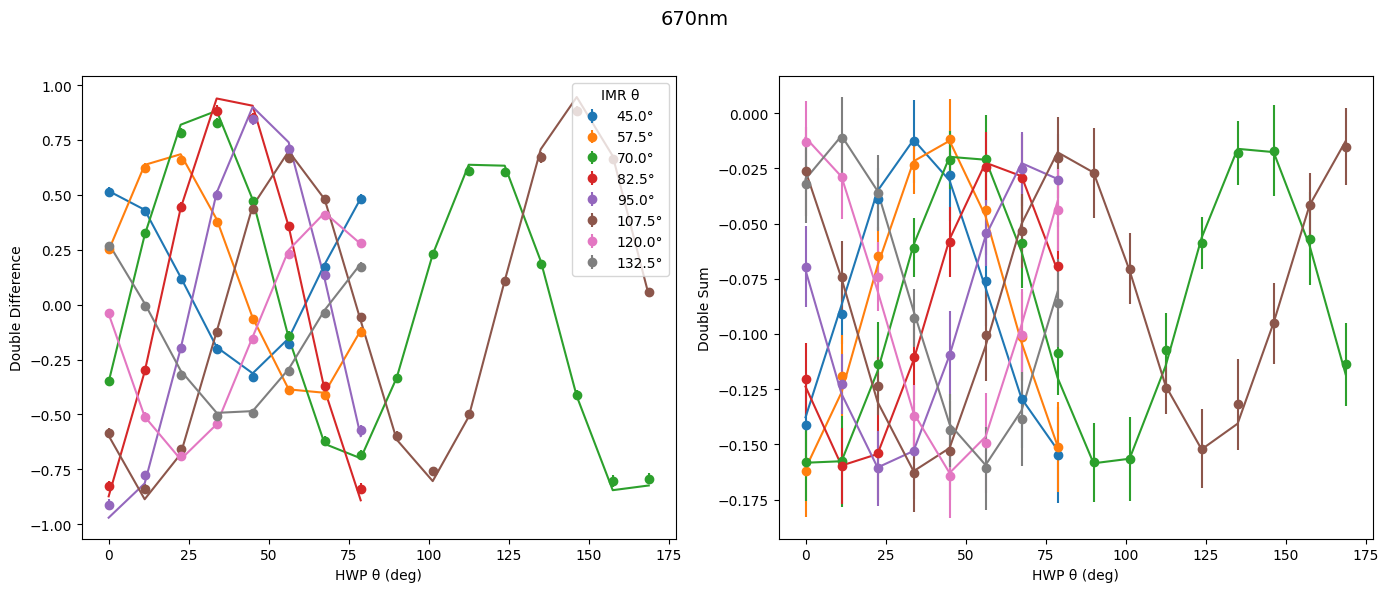

After p0: {'dichroic': {'phi': -1.465887028662888, 'epsilon': 0.0008059826947557839, 'theta': -9.992503643516947}, 'flc': {'phi': 2.5921844844255277, 'delta_theta': -2.971003759307236}, 'optics': {'phi': -2.3492607086822717, 'epsilon': 3.93149009257697e-11, 'theta': -84.54334523491087}, 'image_rotator': {'phi': 1.9872281533174854}, 'hwp': {'phi': 2.892469958194449, 'delta_theta': -0.3783959063077176}, 'lp': {'theta': 1.5938146763643934}}
Before p0: {'dichroic': {'phi': -1.465887028662888, 'epsilon': 0.0008059826947557839, 'theta': -9.992503643516947}, 'flc': {'phi': 2.5921844844255277, 'delta_theta': -2.971003759307236}, 'optics': {'phi': -2.3492607086822717, 'epsilon': 3.93149009257697e-11, 'theta': -84.54334523491087}, 'image_rotator': {'phi': 1.9872281533174854}, 'hwp': {'phi': 2.892469958194449, 'delta_theta': -0.3783959063077176}, 'lp': {'theta': 1.5938146763643934}}
Iteration #: 26
logl_value: 52.19113128731909
Best Fit Parameters: [-1.46588703e+00  8.05982695e-04 -9.99250364e+00

In [14]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds_dict = {
    "dichroic": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "flc": {
        "phi": (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),
        "delta_theta": (-5, 5)
    },
    "optics": {
        "phi": (-np.pi, np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "image_rotator": {
        "phi": (-2 * np.pi, 2 * np.pi),
    },
    "hwp": {
        "phi": (
             (-2 * np.pi, 2 * np.pi)
        ),
        "delta_theta": (-5, 5)
    },
    "lp": {
        "theta": (-5, 5)
    }
}

# Now flatten the bounds in the same order as p0_keywords
p0_values, p0_keywords = inst.parse_configuration(p0)
for (comp, param), val in zip(p0_keywords, p0_values):
    lower, upper = bounds_dict[comp][param]
    if not (lower <= val <= upper):
        print(f"{comp}.{param} = {val} is outside bounds {lower} to {upper}")
bounds = [bounds_dict[comp][param] for comp, param in p0_keywords]

# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_no_retardance_constraints_iterate_on_any_improvement_with_dichroic_best_fit_old_fit_values.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

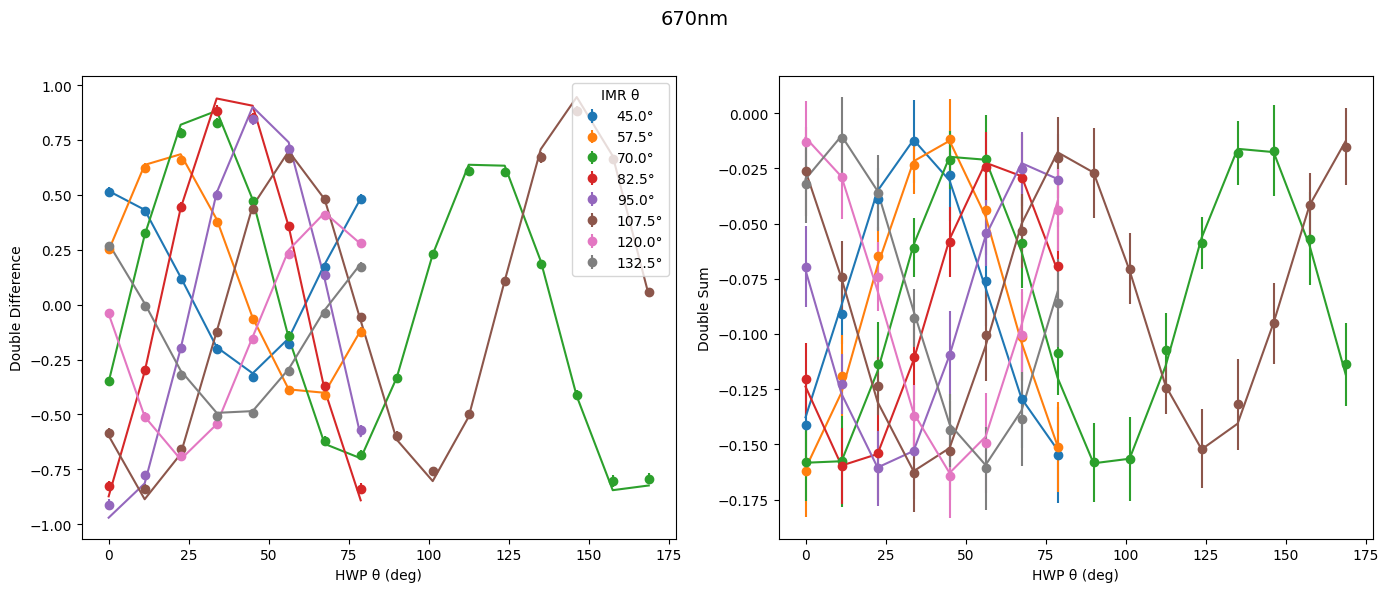

In [15]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)